# BanglaT5 Dialect-to-Standard Bengali — Final Notebook

**Before running:** `Runtime -> Change runtime type -> T4 GPU`, then `Runtime -> Run all`.

This notebook has a single execution route from top to bottom. There is no
separate "rescue" path to choose — every cell only needs to run once, in
order, and the final report ZIP is produced automatically at the end.

In [1]:
# Section 1: Environment setup (Colab + GPU detection)

import sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Google Colab:", IN_COLAB)
print("Python version:", sys.version.split()[0])

if not IN_COLAB:
    print(
        "WARNING: This notebook is designed for Google Colab. "
        "Some cells (file upload, GPU checks) assume a Colab runtime."
    )


Running in Google Colab: True
Python version: 3.13.15


In [2]:
# GPU check -- do this before installing anything, so a missing GPU
# fails fast instead of after a slow package install.

import subprocess

try:
    gpu_report = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    print("Detected GPU(s):")
    print(gpu_report)
except Exception:
    gpu_report = None
    print("nvidia-smi could not be reached; checking via PyTorch instead.")

print(
    "\nIf no GPU is listed above, go to "
    "Runtime -> Change runtime type -> T4 GPU, then Runtime -> Run all."
)


Detected GPU(s):
Tesla T4, 15360 MiB

If no GPU is listed above, go to Runtime -> Change runtime type -> T4 GPU, then Runtime -> Run all.


# Section 2: Package installation

In [3]:
%pip install -q "transformers>=4.44,<5" "datasets>=2.20" "accelerate>=0.33" sentencepiece sacrebleu bert-score sentence-transformers openpyxl seaborn scipy scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 9.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


# Section 3: Imports and locked configuration

In [4]:
import os, re, json, math, time, random, shutil, platform, sys, warnings, inspect
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch
import sacrebleu
import transformers
import datasets

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from transformers import set_seed

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

# ---------------- LOCKED EXPERIMENT CONFIG ----------------
SEED = 42
MODEL_NAME = "csebuetnlp/banglat5"

REGIONS = [
    "Pabna",
    "Noakhali",
    "Jashore",
    "Rangpur",
    "Mymensingh",
    "Barishal",
    "Chittagong",
]

STANDARD_COL = "Standard Bangla"
ID_COL = "ID"

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

LEARNING_RATE = 1e-4
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3

TRAIN_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2
EVAL_BATCH_SIZE = 16

LABEL_SMOOTHING = 0.10
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0

BALANCE_LOW_RESOURCE_REGIONS = True

DECODING_TUNE_SAMPLES_PER_REGION = 50
DECODING_CANDIDATES = [1, 4, 6]

BOOTSTRAP_SAMPLES = 300
BERTSCORE_MODEL = "bert-base-multilingual-cased"

AUTO_DOWNLOAD_REPORT_ZIP = True
CREATE_MODEL_ZIP = False

# Set this to True to reuse an already-trained model saved at MODEL_DIR
# (or a checkpoint inside OUTPUT_ROOT) instead of training again.
REUSE_EXISTING_MODEL_IF_FOUND = True

OUTPUT_ROOT = Path("banglat5_final_outputs")
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
MODEL_DIR = OUTPUT_ROOT / "banglat5_model"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"

for folder in [OUTPUT_ROOT, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. In Colab select "
        "Runtime -> Change runtime type -> T4 GPU, then rerun."
    )

GPU_NAME = torch.cuda.get_device_name(0)
BF16_SUPPORTED = bool(torch.cuda.is_bf16_supported())

if torch.cuda.get_device_capability(0)[0] >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True

print("GPU:", GPU_NAME)
print("BF16 supported:", BF16_SUPPORTED)
print("FP16 enabled: False")
print("Effective train batch size:", TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print("Output folder:", OUTPUT_ROOT.resolve())


GPU: Tesla T4
BF16 supported: True
FP16 enabled: False
Effective train batch size: 16
Output folder: /content/banglat5_final_outputs


# Section 4: Upload and validate the dataset

In [5]:
# Section 4: Upload and validate the Excel/CSV dataset
#
# - Accepts .xlsx or .csv
# - Detects column names that differ only in case, spaces, underscores
#   or common aliases
# - If several compatible files are present, picks the most recently
#   modified one and prints every candidate name it considered
# - Prints filename, shape, detected columns, missing-value summary,
#   region counts and a short preview
# - Stops with a clear error naming exactly which columns are missing

from google.colab import files


def _normalize_column_name(name):
    return re.sub(r"[\s_]+", "", str(name).strip().lower())


REQUIRED_COLUMNS = [ID_COL, STANDARD_COL, *REGIONS]
_REQUIRED_LOOKUP = {_normalize_column_name(c): c for c in REQUIRED_COLUMNS}

# Common aliases beyond simple case/space/underscore differences.
_COLUMN_ALIASES = {
    "id": ID_COL,
    "sentenceid": ID_COL,
    "sl": ID_COL,
    "slno": ID_COL,
    "standardbangla": STANDARD_COL,
    "standardbengali": STANDARD_COL,
    "standard": STANDARD_COL,
    "bangla": STANDARD_COL,
}
for _alias, _canonical in _COLUMN_ALIASES.items():
    _REQUIRED_LOOKUP.setdefault(_normalize_column_name(_alias), _canonical)


def read_header(path):
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, nrows=0).columns.astype(str).str.strip().tolist()
    return pd.read_excel(path, nrows=0).columns.astype(str).str.strip().tolist()


def read_full(path):
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, dtype=str)
    return pd.read_excel(path, dtype=str)


def map_columns_to_canonical(header):
    """Return {canonical_name: actual_column_name_in_file}."""
    mapping = {}
    for actual in header:
        canonical = _REQUIRED_LOOKUP.get(_normalize_column_name(actual))
        if canonical and canonical not in mapping:
            mapping[canonical] = actual
    return mapping


def find_candidate_files():
    search_dirs = [Path("."), Path("/content")]
    seen = set()
    candidates = []
    for directory in search_dirs:
        if not directory.exists():
            continue
        for pattern in ("*.xlsx", "*.csv"):
            for path in sorted(directory.glob(pattern)):
                resolved = path.resolve()
                if resolved not in seen:
                    seen.add(resolved)
                    candidates.append(resolved)
    return candidates


def find_master_dataset():
    """Return (path, column_mapping) for the newest compatible file, or (None, None)."""
    valid = []
    for path in find_candidate_files():
        try:
            header = read_header(path)
        except Exception:
            continue

        mapping = map_columns_to_canonical(header)
        if set(mapping.keys()) == set(REQUIRED_COLUMNS):
            valid.append((path, mapping))

    if not valid:
        return None, None

    valid.sort(key=lambda item: item[0].stat().st_mtime, reverse=True)

    if len(valid) > 1:
        print(
            "Multiple compatible dataset files were found; "
            "using the most recently modified one."
        )
        for path, _ in valid:
            print("  -", path.name)

    return valid[0]


DATA_FILE, COLUMN_MAPPING = find_master_dataset()

if DATA_FILE is None:
    print("Upload the master dataset file (.xlsx or .csv).")
    files.upload()
    DATA_FILE, COLUMN_MAPPING = find_master_dataset()

if DATA_FILE is None:
    all_seen = find_candidate_files()
    if all_seen:
        seen_headers = {p.name: read_header(p) for p in all_seen}
    else:
        seen_headers = {}
    raise FileNotFoundError(
        "No uploaded .xlsx/.csv file contains all required master-dataset "
        f"columns: {REQUIRED_COLUMNS}. Files checked: {seen_headers}"
    )

raw_df = read_full(DATA_FILE)

# Rename detected columns to their canonical names (handles case,
# spacing, underscore and known-alias differences).
raw_df = raw_df.rename(columns={actual: canonical for canonical, actual in COLUMN_MAPPING.items()})
raw_df.columns = [str(c).strip() for c in raw_df.columns]
raw_df = raw_df.dropna(how="all").copy()

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(raw_df.columns))
if missing_columns:
    raise ValueError(
        f"Required columns are missing after alias detection: {missing_columns}. "
        f"Required columns are: {REQUIRED_COLUMNS}"
    )

print("Selected file:", DATA_FILE.name)
print("Dataset shape:", raw_df.shape)
print("Detected columns:", raw_df.columns.tolist())

missing_summary = raw_df[REQUIRED_COLUMNS].isna().sum().rename("Missing_Values").to_frame()
missing_summary["Missing_Percent"] = (100 * missing_summary["Missing_Values"] / len(raw_df)).round(2)
print("\nMissing-value summary:")
display(missing_summary)

region_counts = raw_df[REGIONS].notna().sum().rename("Non_Empty_Sentences").to_frame()
print("\nRegion counts (non-empty sentences per region):")
display(region_counts)

print("\nPreview:")
display(raw_df.head(3))


Selected file: Master_sheet_Dataset.xlsx
Dataset shape: (2500, 11)
Detected columns: ['ID', 'Standard Bangla', 'Banglish', 'English', 'Pabna', 'Noakhali', 'Jashore', 'Rangpur', 'Mymensingh', 'Barishal', 'Chittagong']

Missing-value summary:


,Missing_Values,Missing_Percent
ID,0,0.0
Standard Bangla,0,0.0
Pabna,0,0.0
Noakhali,0,0.0
Jashore,0,0.0
Rangpur,0,0.0
Mymensingh,1000,40.0
Barishal,1000,40.0
Chittagong,1370,54.8



Region counts (non-empty sentences per region):


,Non_Empty_Sentences
Pabna,2500
Noakhali,2500
Jashore,2500
Rangpur,2500
Mymensingh,1500
Barishal,1500
Chittagong,1130



Preview:


,ID,Standard Bangla,Banglish,English,Pabna,Noakhali,Jashore,Rangpur,Mymensingh,Barishal,Chittagong
0,0001,কেমন আছো ?,Kemon acho?,How are you?,ক্যাবা আছ্যাও?,কেরুম আছত,কিরাম আছো ?,ক্যাংকা আছিস?,কিরম আছুইন?,কিরম আছো?,ক্যান আছ্?
1,0002,আজকে আমার মন ভালো নেই,Ajke amar mon bhalo nei,I am not in a good mood today.,আইজকি আমার মন বালো নাই,আজ্জা আর মন ভালা নাই।,আজকে আমার মনডা ভালো নেই।,আইজক্যা মোর মন ভালো নাই,আজ্জওয়া আমার মন বালা না,আইজগো মোর মোন ডা ভালো নাই।,আইজ্জ্যা আঁর মন বালা নাই
2,0003,তুমি কি করো ?,Tumi ki koro?,What do you do?,তুমি কি হরো?,তুই কিয়া রছ?,তুমি কি করো ?,তুই কি করিস?,তুমি কিতা কর?,তুই কি হরো?,তুই কি গর


# Section 5: Text preprocessing and data-quality audit

In [6]:
import unicodedata

ZERO_WIDTH_PATTERN = re.compile("[\u200b\u200c\u200d\ufeff]")
WHITESPACE_PATTERN = re.compile(r"\s+")


def clean_text(value):
    if pd.isna(value):
        return pd.NA

    value = unicodedata.normalize("NFC", str(value))
    value = ZERO_WIDTH_PATTERN.sub("", value)
    value = WHITESPACE_PATTERN.sub(" ", value).strip()

    return value if value else pd.NA


TEXT_COLUMNS = [c for c in [STANDARD_COL, "Banglish", "English", *REGIONS] if c in raw_df.columns]

audit_rows = []

for col in TEXT_COLUMNS:
    original = raw_df[col]
    original_text = original.dropna().astype(str)
    cleaned = original.apply(clean_text)

    changed = sum(
        str(a) != str(b)
        for a, b in zip(original.tolist(), cleaned.tolist())
        if not (pd.isna(a) and pd.isna(b))
    )

    audit_rows.append({
        "Column": col,
        "Non_empty_before": int(original_text.str.strip().ne("").sum()),
        "NFC_changes": int(sum(unicodedata.normalize("NFC", x) != x for x in original_text)),
        "Rows_with_zero_width": int(original_text.str.contains(ZERO_WIDTH_PATTERN).sum()),
        "Rows_changed_by_cleaning": int(changed),
        "Non_empty_after": int(cleaned.notna().sum()),
    })

    raw_df[col] = cleaned


df = raw_df.dropna(subset=[STANDARD_COL]).copy()

df[ID_COL] = df[ID_COL].astype("string").str.strip()

if df[ID_COL].isna().any() or df[ID_COL].eq("").any():
    raise ValueError("Missing sentence IDs found. Correct the master sheet before training.")

df[ID_COL] = df[ID_COL].str.replace(r"\.0$", "", regex=True).str.zfill(4)

if df[ID_COL].duplicated().any():
    dupes = df.loc[df[ID_COL].duplicated(False), ID_COL].unique().tolist()[:10]
    raise ValueError(f"Duplicate IDs found in wide-format master sheet: {dupes}")

duplicate_target_mask = df[STANDARD_COL].duplicated(keep=False)
duplicate_targets_df = df.loc[duplicate_target_mask, [ID_COL, STANDARD_COL]].sort_values(STANDARD_COL)
duplicate_target_extra_rows = int(df[STANDARD_COL].duplicated().sum())

if duplicate_target_extra_rows:
    print(
        f"NOTE: normalization reveals {duplicate_target_extra_rows} repeated "
        "Standard Bengali target row(s). Their IDs will be linked into the "
        "same split group to prevent target leakage."
    )

quality_audit_df = pd.DataFrame(audit_rows)

coverage_rows = []
for region in REGIONS:
    nonempty = int(df[region].notna().sum())
    identical = int((df[region].fillna("") == df[STANDARD_COL].fillna("")).sum())
    coverage_rows.append({
        "Region": region,
        "Available_Sentences": nonempty,
        "Coverage_Percent": round(100 * nonempty / len(df), 2),
        "Exact_Same_as_Standard": identical,
        "Exact_Same_Percent": round(100 * identical / max(nonempty, 1), 2),
    })

coverage_df = pd.DataFrame(coverage_rows)

dataset_summary_df = pd.DataFrame([{
    "Standard_Sentences": len(df),
    "Unique_IDs": df[ID_COL].nunique(),
    "Unique_Standard_Targets": df[STANDARD_COL].nunique(),
    "Repeated_Target_Extra_Rows_After_Cleaning": duplicate_target_extra_rows,
    "Fully_Parallel_Seven_Region_Rows": int(df[REGIONS].notna().all(axis=1).sum()),
    "Total_Dialect_Standard_Pairs": int(df[REGIONS].notna().sum().sum()),
}])

quality_audit_df.to_csv(TABLE_DIR / "data_cleaning_audit.csv", index=False)
coverage_df.to_csv(TABLE_DIR / "regional_coverage.csv", index=False)
dataset_summary_df.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)
duplicate_targets_df.to_csv(TABLE_DIR / "normalized_duplicate_target_audit.csv", index=False)

display(dataset_summary_df)
display(coverage_df)
display(quality_audit_df)


NOTE: normalization reveals 1 repeated Standard Bengali target row(s). Their IDs will be linked into the same split group to prevent target leakage.


,Standard_Sentences,Unique_IDs,Unique_Standard_Targets,Repeated_Target_Extra_Rows_After_Cleaning,Fully_Parallel_Seven_Region_Rows,Total_Dialect_Standard_Pairs
0,2500,2500,2499,1,1130,14130


,Region,Available_Sentences,Coverage_Percent,Exact_Same_as_Standard,Exact_Same_Percent
0,Pabna,2500,100.0,23,0.92
1,Noakhali,2500,100.0,16,0.64
2,Jashore,2500,100.0,871,34.84
3,Rangpur,2500,100.0,56,2.24
4,Mymensingh,1500,60.0,16,1.07
5,Barishal,1500,60.0,15,1.00
6,Chittagong,1130,45.2,5,0.44


,Column,Non_empty_before,NFC_changes,Rows_with_zero_width,Rows_changed_by_cleaning,Non_empty_after
0,Standard Bangla,2500,993,0,1086,2500
1,Banglish,2500,0,0,0,2500
2,English,2500,0,0,2,2500
3,Pabna,2500,1375,5,1533,2500
4,Noakhali,2500,738,0,770,2500
5,Jashore,2500,1039,0,1119,2500
6,Rangpur,2500,813,2,1426,2500
7,Mymensingh,1500,814,0,815,1500
8,Barishal,1500,248,0,984,1500
9,Chittagong,1130,498,2,566,1130


# Section 6: Regional dataset coverage figure

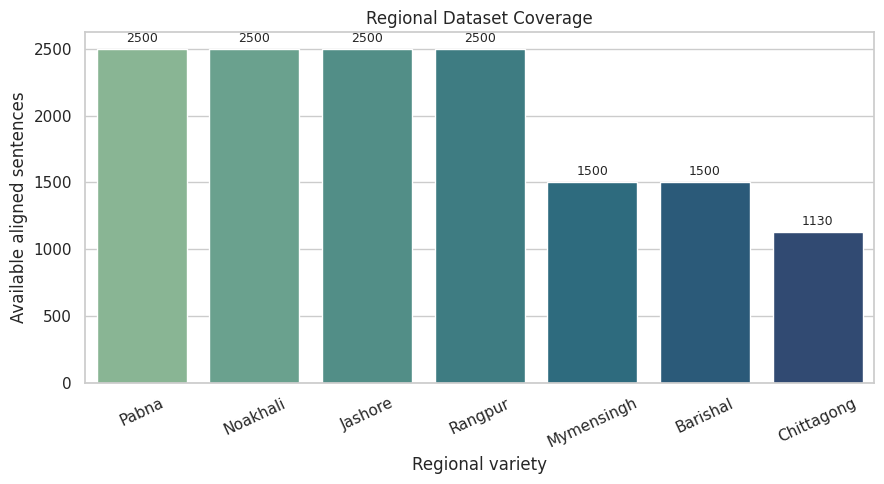

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    # Auto-download this figure the moment it is created, so it is safe on
    # your computer even if a later cell fails or the runtime disconnects.
    try:
        from google.colab import files
        files.download(str(FIG_DIR / filename))
    except Exception as download_error:
        print(f"Auto-download skipped for {filename}: {download_error}")


plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=coverage_df,
    x="Region",
    y="Available_Sentences",
    hue="Region",
    palette="crest",
    legend=False,
)

ax.set_title("Regional Dataset Coverage")
ax.set_xlabel("Regional variety")
ax.set_ylabel("Available aligned sentences")
ax.tick_params(axis="x", rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

save_figure("figure_01_regional_dataset_coverage.png")


# Section 7: Wide-to-long conversion — generate dialect-to-standard pairs

In [8]:
pairs = []

for region in REGIONS:
    sub = df[[ID_COL, STANDARD_COL, region]].dropna(subset=[STANDARD_COL, region])

    for row in sub.itertuples(index=False, name=None):
        sentence_id, target_text, dialect_text = row
        pairs.append({
            "id": sentence_id,
            "region": region,
            "dialect_text": dialect_text,
            "source_text": f"translate {region} to Bangla: {dialect_text}",
            "target_text": target_text,
        })

pairs_df = pd.DataFrame(pairs)

if pairs_df.empty:
    raise ValueError("No dialect-standard pairs were created.")

targets_per_id = pairs_df.groupby("id")["target_text"].nunique()

if int(targets_per_id.max()) != 1:
    raise ValueError("At least one ID maps to multiple Standard Bangla targets.")

long_summary_df = (
    pairs_df.groupby("region", sort=False)
    .agg(
        Pairs=("id", "size"),
        Unique_IDs=("id", "nunique"),
        Mean_Dialect_Words=("dialect_text", lambda s: round(s.str.split().str.len().mean(), 2)),
        Mean_Target_Words=("target_text", lambda s: round(s.str.split().str.len().mean(), 2)),
    )
    .reset_index()
)

long_summary_df.to_csv(TABLE_DIR / "long_format_summary.csv", index=False)

print("Total long-format pairs:", len(pairs_df))
display(long_summary_df)


Total long-format pairs: 14130


,region,Pairs,Unique_IDs,Mean_Dialect_Words,Mean_Target_Words
0,Pabna,2500,2500,6.66,6.67
1,Noakhali,2500,2500,6.34,6.67
2,Jashore,2500,2500,6.62,6.67
3,Rangpur,2500,2500,6.76,6.67
4,Mymensingh,1500,1500,6.77,6.83
5,Barishal,1500,1500,6.92,6.83
6,Chittagong,1130,1130,6.69,6.63


# Section 8: Dataset and methodology diagrams

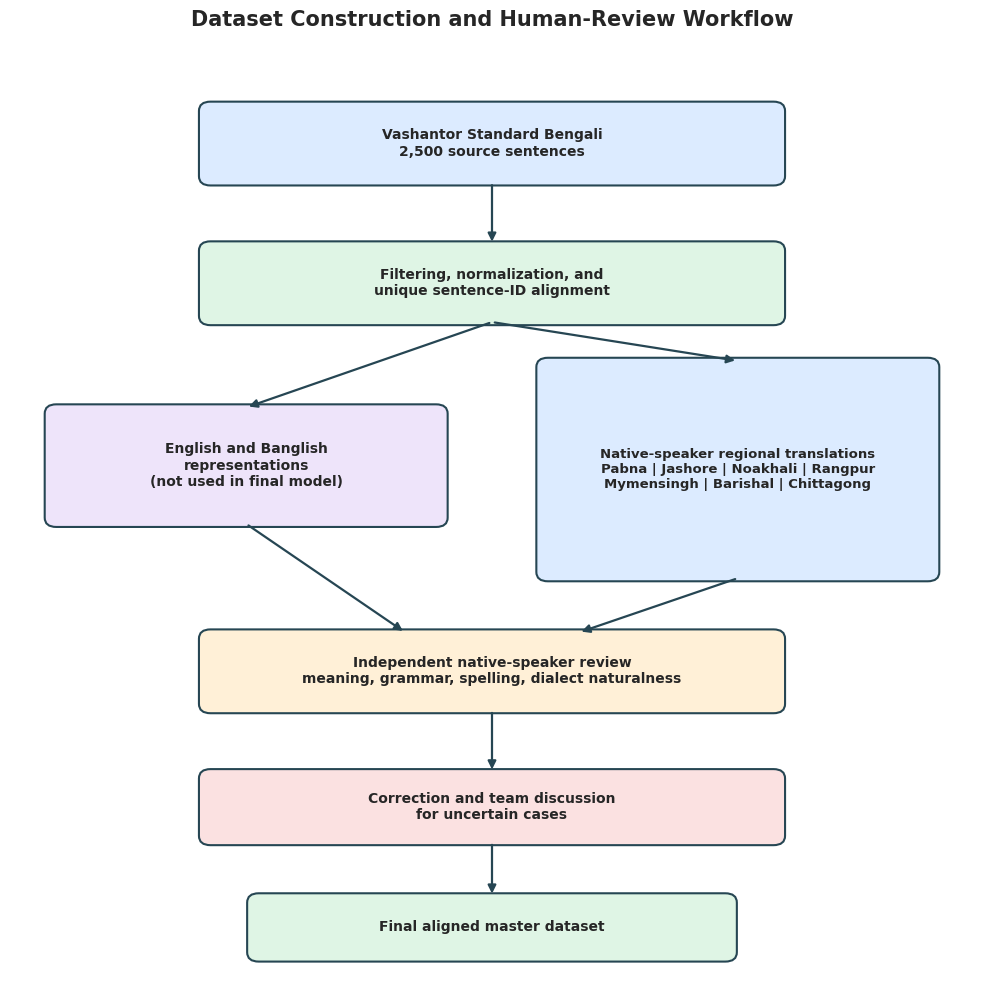

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

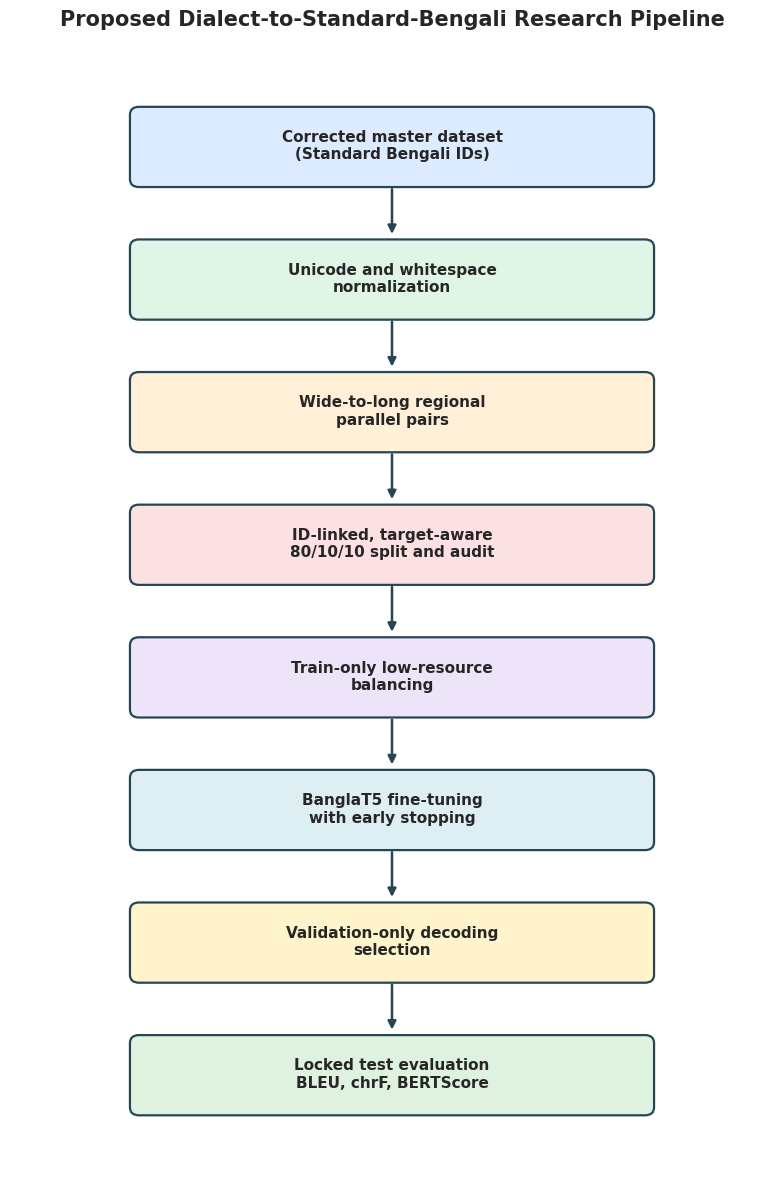

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# Dataset-construction and human-review workflow

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis("off")


def flow_box(x, y, width, height, text, color, edge="#264653", fontsize=10):
    box = patches.FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=.04,rounding_size=.12",
        linewidth=1.5, edgecolor=edge, facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=fontsize, weight="bold")


flow_box(2, 10.2, 6, 1.0, "Vashantor Standard Bengali\n2,500 source sentences", "#DCEBFF")
flow_box(2, 8.4, 6, 1.0, "Filtering, normalization, and\nunique sentence-ID alignment", "#DFF5E5")
flow_box(0.4, 5.8, 4.1, 1.5, "English and Banglish\nrepresentations\n(not used in final model)", "#EEE4FA")
flow_box(
    5.5, 5.1, 4.1, 2.8,
    "Native-speaker regional translations\n"
    "Pabna | Jashore | Noakhali | Rangpur\n"
    "Mymensingh | Barishal | Chittagong",
    "#DCEBFF", fontsize=9.5,
)
flow_box(2, 3.4, 6, 1.0, "Independent native-speaker review\nmeaning, grammar, spelling, dialect naturalness", "#FFF0D7")
flow_box(2, 1.7, 6, 0.9, "Correction and team discussion\nfor uncertain cases", "#FBE1E1")
flow_box(2.5, 0.2, 5, 0.8, "Final aligned master dataset", "#DFF5E5")

workflow_arrows = [
    ((5, 10.2), (5, 9.4)),
    ((5, 8.4), (2.45, 7.3)),
    ((5, 8.4), (7.55, 7.9)),
    ((2.45, 5.8), (4.1, 4.4)),
    ((7.55, 5.1), (5.9, 4.4)),
    ((5, 3.4), (5, 2.6)),
    ((5, 1.7), (5, 1.0)),
]

for start, end in workflow_arrows:
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "-|>", "lw": 1.6, "color": "#264653"})

ax.set_title("Dataset Construction and Human-Review Workflow", fontsize=15, weight="bold", pad=12)
save_figure("figure_02_dataset_construction_review.png")


# Complete methodology pipeline diagram

steps = [
    "Corrected master dataset\n(Standard Bengali IDs)",
    "Unicode and whitespace\nnormalization",
    "Wide-to-long regional\nparallel pairs",
    "ID-linked, target-aware\n80/10/10 split and audit",
    "Train-only low-resource\nbalancing",
    "BanglaT5 fine-tuning\nwith early stopping",
    "Validation-only decoding\nselection",
    "Locked test evaluation\nBLEU, chrF, BERTScore",
]

colors = ["#DCEBFF", "#DFF5E5", "#FFF0D7", "#FBE1E1", "#EEE4FA", "#DDEFF2", "#FFF4CC", "#DFF2DF"]

fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 17)
ax.axis("off")

y_positions = np.linspace(15.5, 1.5, len(steps))

for index, (label, y, color) in enumerate(zip(steps, y_positions, colors)):
    box = patches.FancyBboxPatch(
        (1.6, y - 0.6), 6.8, 1.15,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=1.6, edgecolor="#264653", facecolor=color,
    )
    ax.add_patch(box)
    ax.text(5, y, label, ha="center", va="center", fontsize=11, weight="bold")

    if index < len(steps) - 1:
        ax.annotate(
            "", xy=(5, y_positions[index + 1] + 0.62), xytext=(5, y - 0.62),
            arrowprops={"arrowstyle": "-|>", "lw": 1.8, "color": "#264653"},
        )

ax.set_title("Proposed Dialect-to-Standard-Bengali Research Pipeline", fontsize=15, weight="bold", pad=15)
save_figure("figure_03_proposed_methodology_pipeline.png")


# Section 9: Leakage-safe dataset splitting — ID-grouped 80/10/10 split

In [10]:
unique_ids = np.array(sorted(pairs_df["id"].unique()))
unique_target_groups = np.array(sorted(pairs_df["target_text"].unique()))

train_ids, temporary_ids = train_test_split(unique_ids, test_size=0.20, random_state=SEED, shuffle=True)
val_ids, test_ids = train_test_split(temporary_ids, test_size=0.50, random_state=SEED, shuffle=True)

SPLIT_STRATEGY_USED = "ID-grouped 80/10/10"


def make_split_frames(train_id_values, val_id_values, test_id_values):
    return (
        pairs_df[pairs_df["id"].isin(train_id_values)].reset_index(drop=True),
        pairs_df[pairs_df["id"].isin(val_id_values)].reset_index(drop=True),
        pairs_df[pairs_df["id"].isin(test_id_values)].reset_index(drop=True),
    )


train_df_raw, val_df, test_df = make_split_frames(train_ids, val_ids, test_ids)

precheck_target_overlap = {
    "train_validation": len(set(train_df_raw.target_text) & set(val_df.target_text)),
    "train_test": len(set(train_df_raw.target_text) & set(test_df.target_text)),
    "validation_test": len(set(val_df.target_text) & set(test_df.target_text)),
}

if any(precheck_target_overlap.values()):
    print("Cross-split normalized target overlap detected; activating target-grouped fallback.")

    train_target_groups, temporary_target_groups = train_test_split(
        unique_target_groups, test_size=0.20, random_state=SEED, shuffle=True
    )
    val_target_groups, test_target_groups = train_test_split(
        temporary_target_groups, test_size=0.50, random_state=SEED, shuffle=True
    )

    train_ids = pairs_df.loc[pairs_df.target_text.isin(train_target_groups), "id"].unique()
    val_ids = pairs_df.loc[pairs_df.target_text.isin(val_target_groups), "id"].unique()
    test_ids = pairs_df.loc[pairs_df.target_text.isin(test_target_groups), "id"].unique()

    train_df_raw, val_df, test_df = make_split_frames(train_ids, val_ids, test_ids)
    SPLIT_STRATEGY_USED = "Normalized-target-grouped fallback (also preserves ID groups)"

split_map = {sentence_id: "train" for sentence_id in train_ids}
split_map.update({sentence_id: "validation" for sentence_id in val_ids})
split_map.update({sentence_id: "test" for sentence_id in test_ids})

split_assignments_df = pd.DataFrame({
    "ID": unique_ids,
    "Split": [split_map[sentence_id] for sentence_id in unique_ids],
})

split_assignments_df.to_csv(OUTPUT_ROOT / f"split_assignments_seed{SEED}.csv", index=False)

id_overlap = {
    "train_validation": len(set(train_df_raw.id) & set(val_df.id)),
    "train_test": len(set(train_df_raw.id) & set(test_df.id)),
    "validation_test": len(set(val_df.id) & set(test_df.id)),
}

target_overlap = {
    "train_validation": len(set(train_df_raw.target_text) & set(val_df.target_text)),
    "train_test": len(set(train_df_raw.target_text) & set(test_df.target_text)),
    "validation_test": len(set(val_df.target_text) & set(test_df.target_text)),
}

assert all(count == 0 for count in id_overlap.values()), f"ID leakage detected: {id_overlap}"
assert all(count == 0 for count in target_overlap.values()), f"Exact target leakage detected: {target_overlap}"

split_frames = {"Train": train_df_raw, "Validation": val_df, "Test": test_df}
split_rows = []

for split_name, frame in split_frames.items():
    for region in REGIONS:
        split_rows.append({
            "Split": split_name,
            "Region": region,
            "Pairs": int((frame.region == region).sum()),
            "Unique_IDs": int(frame.loc[frame.region == region, "id"].nunique()),
        })

split_summary_df = pd.DataFrame(split_rows)

leakage_audit_df = pd.DataFrame([
    {"Check": "ID overlap: train-validation", "Count": id_overlap["train_validation"], "Required": 0, "Status": "PASS"},
    {"Check": "ID overlap: train-test", "Count": id_overlap["train_test"], "Required": 0, "Status": "PASS"},
    {"Check": "ID overlap: validation-test", "Count": id_overlap["validation_test"], "Required": 0, "Status": "PASS"},
    {"Check": "Target overlap: train-validation", "Count": target_overlap["train_validation"], "Required": 0, "Status": "PASS"},
    {"Check": "Target overlap: train-test", "Count": target_overlap["train_test"], "Required": 0, "Status": "PASS"},
    {"Check": "Target overlap: validation-test", "Count": target_overlap["validation_test"], "Required": 0, "Status": "PASS"},
])

split_summary_df.to_csv(TABLE_DIR / "split_distribution.csv", index=False)
leakage_audit_df.to_csv(TABLE_DIR / "leakage_audit.csv", index=False)

print("Split strategy used:", SPLIT_STRATEGY_USED)
print("Unique normalized target groups:", len(unique_target_groups))
print("Unique ID split:", len(train_ids), len(val_ids), len(test_ids))
print("Pair split:", len(train_df_raw), len(val_df), len(test_df))

display(leakage_audit_df)
display(split_summary_df.pivot(index="Region", columns="Split", values="Pairs").reindex(REGIONS))


Split strategy used: ID-grouped 80/10/10
Unique normalized target groups: 2499
Unique ID split: 2000 250 250
Pair split: 11316 1395 1419


,Check,Count,Required,Status
0,ID overlap: train-validation,0,0,PASS
1,ID overlap: train-test,0,0,PASS
2,ID overlap: validation-test,0,0,PASS
3,Target overlap: train-validation,0,0,PASS
4,Target overlap: train-test,0,0,PASS
5,Target overlap: validation-test,0,0,PASS


Split,Test,Train,Validation
Region,,,
Pabna,250,2000,250
Noakhali,250,2000,250
Jashore,250,2000,250
Rangpur,250,2000,250
Mymensingh,153,1204,143
Barishal,153,1204,143
Chittagong,113,908,109


# Section 10: Split distribution and leakage diagram

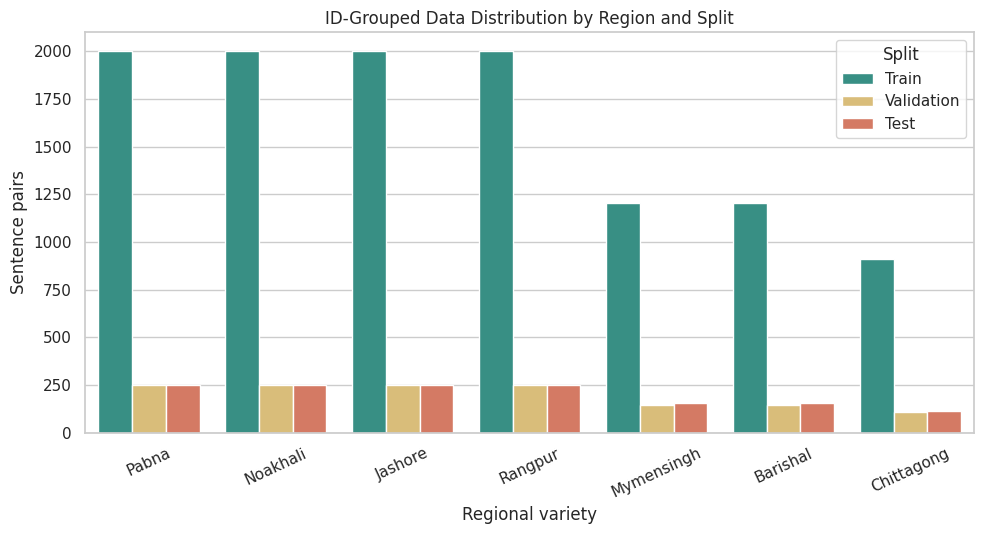

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

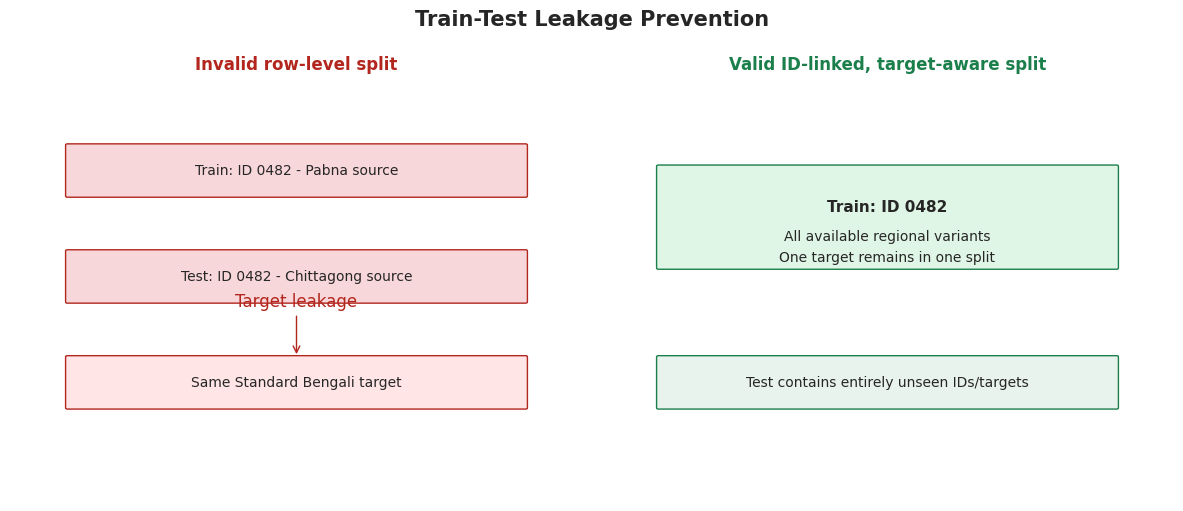

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=split_summary_df, x="Region", y="Pairs", hue="Split",
    palette=["#2A9D8F", "#E9C46A", "#E76F51"],
)

ax.set_title("ID-Grouped Data Distribution by Region and Split")
ax.set_xlabel("Regional variety")
ax.set_ylabel("Sentence pairs")
ax.tick_params(axis="x", rotation=25)

save_figure("figure_04_grouped_split_distribution.png")


# Leakage-prevention diagram

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

for current_axis in axes:
    current_axis.axis("off")
    current_axis.set_xlim(0, 10)
    current_axis.set_ylim(0, 10)

axes[0].set_title("Invalid row-level split", weight="bold", color="#B3261E")

invalid_boxes = [
    (7.2, "Train: ID 0482 - Pabna source", "#F8D7DA"),
    (4.7, "Test: ID 0482 - Chittagong source", "#F8D7DA"),
    (2.2, "Same Standard Bengali target", "#FFE5E5"),
]

for y, label, color in invalid_boxes:
    axes[0].add_patch(patches.FancyBboxPatch((1, y), 8, 1.2, boxstyle="round,pad=.03", facecolor=color, edgecolor="#B3261E"))
    axes[0].text(5, y + 0.6, label, ha="center", va="center", fontsize=10)

axes[0].annotate(
    "Target leakage", xy=(5, 3.4), xytext=(5, 4.6), ha="center", color="#B3261E",
    arrowprops={"arrowstyle": "->", "color": "#B3261E"},
)

axes[1].set_title("Valid ID-linked, target-aware split", weight="bold", color="#1B7F4B")

axes[1].add_patch(patches.FancyBboxPatch((1, 5.5), 8, 2.4, boxstyle="round,pad=.03", facecolor="#DFF5E5", edgecolor="#1B7F4B"))
axes[1].text(5, 6.95, "Train: ID 0482", ha="center", va="center", fontsize=11, weight="bold")
axes[1].text(5, 6.25, "All available regional variants", ha="center", va="center", fontsize=10)
axes[1].text(5, 5.75, "One target remains in one split", ha="center", va="center", fontsize=10)

axes[1].add_patch(patches.FancyBboxPatch((1, 2.2), 8, 1.2, boxstyle="round,pad=.03", facecolor="#E8F3ED", edgecolor="#1B7F4B"))
axes[1].text(5, 2.8, "Test contains entirely unseen IDs/targets", ha="center", va="center", fontsize=10)

fig.suptitle("Train-Test Leakage Prevention", fontsize=15, weight="bold")
save_figure("figure_05_target_leakage_prevention.png")


# Section 11: Train-only regional balancing

Balancing target: 2000
Training pairs before/after: 11316 14000


,Region,Original_Train_Pairs,Balanced_Train_Pairs,Added_Training_Instances,Unique_Training_Pairs
0,Pabna,2000,2000,0,2000
1,Noakhali,2000,2000,0,2000
2,Jashore,2000,2000,0,2000
3,Rangpur,2000,2000,0,2000
4,Mymensingh,1204,2000,796,1204
5,Barishal,1204,2000,796,1204
6,Chittagong,908,2000,1092,908


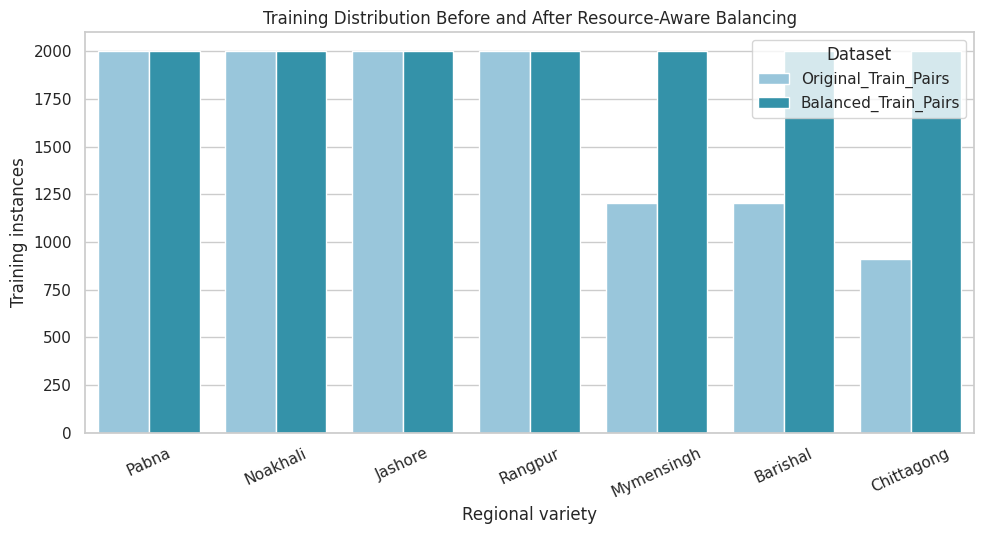

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
before_counts = train_df_raw["region"].value_counts().reindex(REGIONS).fillna(0).astype(int)
balance_target = int(before_counts.median())

balanced_parts = []
balance_records = []

for index, region in enumerate(REGIONS):
    region_df = train_df_raw[train_df_raw.region == region].copy()
    original_count = len(region_df)

    if BALANCE_LOW_RESOURCE_REGIONS and 0 < original_count < balance_target:
        extra = region_df.sample(n=balance_target - original_count, replace=True, random_state=SEED + index)
        region_balanced = pd.concat([region_df, extra], ignore_index=True)
    else:
        region_balanced = region_df

    balanced_parts.append(region_balanced)

    balance_records.append({
        "Region": region,
        "Original_Train_Pairs": original_count,
        "Balanced_Train_Pairs": len(region_balanced),
        "Added_Training_Instances": len(region_balanced) - original_count,
        "Unique_Training_Pairs": region_df[["id", "region"]].drop_duplicates().shape[0],
    })

train_df = pd.concat(balanced_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
balance_df = pd.DataFrame(balance_records)
balance_df.to_csv(TABLE_DIR / "train_balancing_summary.csv", index=False)

assert set(train_df.id).issubset(set(train_ids))
assert set(train_df.id).isdisjoint(set(val_ids))
assert set(train_df.id).isdisjoint(set(test_ids))

print("Balancing target:", balance_target)
print("Training pairs before/after:", len(train_df_raw), len(train_df))
display(balance_df)

balance_plot_df = balance_df.melt(
    id_vars="Region", value_vars=["Original_Train_Pairs", "Balanced_Train_Pairs"],
    var_name="Dataset", value_name="Pairs",
)

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=balance_plot_df, x="Region", y="Pairs", hue="Dataset",
    palette=["#8ECAE6", "#219EBC"],
)

ax.set_title("Training Distribution Before and After Resource-Aware Balancing")
ax.set_xlabel("Regional variety")
ax.set_ylabel("Training instances")
ax.tick_params(axis="x", rotation=25)

save_figure("figure_06_training_distribution_balancing.png")


# Section 12: Tokenization and length analysis — load BanglaT5 and inspect token lengths

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

,Field,Mean_Tokens,P95_Tokens,P99_5_Tokens,Maximum_Tokens,Selected_Max_Length,Truncation_Rate_Percent
0,Source,19.15,27.0,34.0,48,40,0.09
1,Target,8.10,14.0,17.0,23,32,0.00


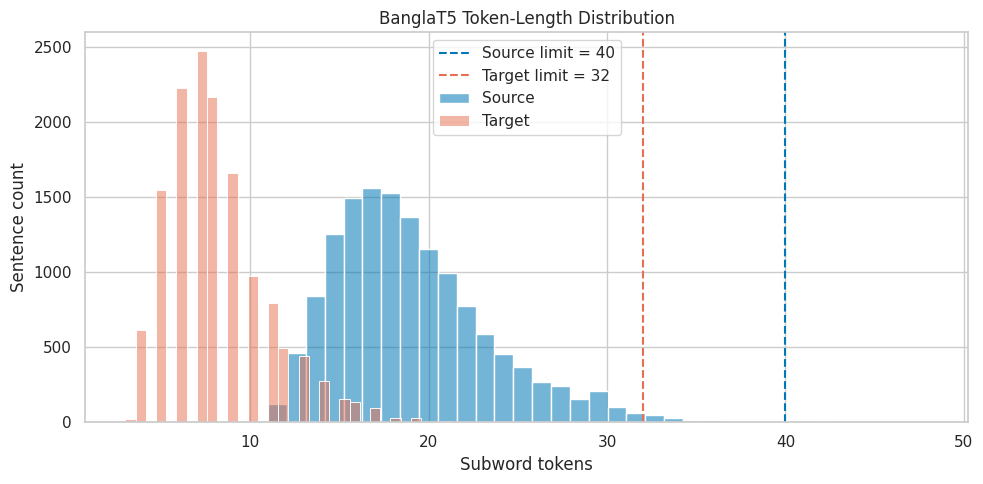

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

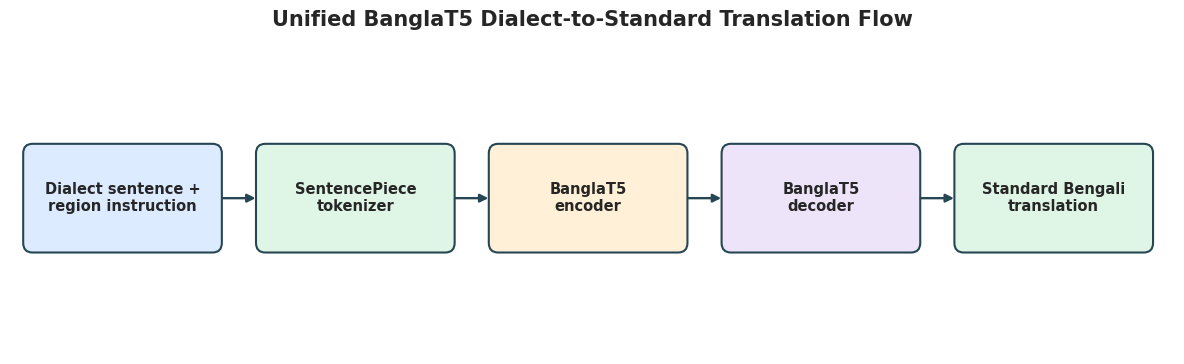

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

source_probe = pairs_df["source_text"].tolist()
target_probe = pairs_df["target_text"].tolist()

source_lengths = [
    len(token_ids)
    for token_ids in tokenizer(source_probe, add_special_tokens=True, truncation=False)["input_ids"]
]
target_lengths = [
    len(token_ids)
    for token_ids in tokenizer(target_probe, add_special_tokens=True, truncation=False)["input_ids"]
]


def percentile_length(lengths, percentile=99.5, lower=32, upper=96):
    raw_length = int(math.ceil(np.percentile(lengths, percentile) / 8.0) * 8)
    return int(min(upper, max(lower, raw_length)))


MAX_SOURCE_LEN = percentile_length(source_lengths)
MAX_TARGET_LEN = percentile_length(target_lengths)

source_truncation_rate = 100 * np.mean(np.array(source_lengths) > MAX_SOURCE_LEN)
target_truncation_rate = 100 * np.mean(np.array(target_lengths) > MAX_TARGET_LEN)

token_length_df = pd.DataFrame({
    "Field": ["Source", "Target"],
    "Mean_Tokens": [np.mean(source_lengths), np.mean(target_lengths)],
    "P95_Tokens": [np.percentile(source_lengths, 95), np.percentile(target_lengths, 95)],
    "P99_5_Tokens": [np.percentile(source_lengths, 99.5), np.percentile(target_lengths, 99.5)],
    "Maximum_Tokens": [max(source_lengths), max(target_lengths)],
    "Selected_Max_Length": [MAX_SOURCE_LEN, MAX_TARGET_LEN],
    "Truncation_Rate_Percent": [source_truncation_rate, target_truncation_rate],
})

token_length_df.to_csv(TABLE_DIR / "token_length_analysis.csv", index=False)
display(token_length_df.round(2))

plt.figure(figsize=(10, 5))
sns.histplot(source_lengths, color="#0077B6", label="Source", bins=35, alpha=0.55)
sns.histplot(target_lengths, color="#E76F51", label="Target", bins=35, alpha=0.50)
plt.axvline(MAX_SOURCE_LEN, color="#0077B6", linestyle="--", label=f"Source limit = {MAX_SOURCE_LEN}")
plt.axvline(MAX_TARGET_LEN, color="#E76F51", linestyle="--", label=f"Target limit = {MAX_TARGET_LEN}")
plt.title("BanglaT5 Token-Length Distribution")
plt.xlabel("Subword tokens")
plt.ylabel("Sentence count")
plt.legend()
save_figure("figure_07_token_length_distribution.png")


# BanglaT5 model-flow diagram

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.axis("off")

model_steps = [
    (0.2, "Dialect sentence +\nregion instruction", "#DCEBFF"),
    (3.2, "SentencePiece\ntokenizer", "#DFF5E5"),
    (6.2, "BanglaT5\nencoder", "#FFF0D7"),
    (9.2, "BanglaT5\ndecoder", "#EEE4FA"),
    (12.2, "Standard Bengali\ntranslation", "#DFF5E5"),
]

for index, (x, label, color) in enumerate(model_steps):
    box = patches.FancyBboxPatch(
        (x, 1.3), 2.5, 1.3,
        boxstyle="round,pad=.03,rounding_size=.12",
        linewidth=1.5, edgecolor="#264653", facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x + 1.25, 1.95, label, ha="center", va="center", fontsize=10.5, weight="bold")

    if index < len(model_steps) - 1:
        ax.annotate(
            "", xy=(model_steps[index + 1][0], 1.95), xytext=(x + 2.5, 1.95),
            arrowprops={"arrowstyle": "-|>", "lw": 1.7, "color": "#264653"},
        )

ax.set_title("Unified BanglaT5 Dialect-to-Standard Translation Flow", fontsize=15, weight="bold")
save_figure("figure_08_banglat5_model_flow.png")


# Section 13: Create Hugging Face datasets and tokenize

In [14]:
def to_hf_dataset(frame):
    return Dataset.from_pandas(
        frame[["source_text", "target_text"]].reset_index(drop=True),
        preserve_index=False,
    )


train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)


def tokenize_batch(batch):
    model_inputs = tokenizer(batch["source_text"], max_length=MAX_SOURCE_LEN, truncation=True)
    labels = tokenizer(text_target=batch["target_text"], max_length=MAX_TARGET_LEN, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=train_ds.column_names, desc="Tokenizing train")
val_tok = val_ds.map(tokenize_batch, batched=True, remove_columns=val_ds.column_names, desc="Tokenizing validation")
test_tok = test_ds.map(tokenize_batch, batched=True, remove_columns=test_ds.column_names, desc="Tokenizing test")

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8,
)

print(train_tok)


Tokenizing train:   0%|          | 0/14000 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/1395 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/1419 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 14000
})


# Section 14: BanglaT5 training with early stopping

In [15]:
# Checkpoint handling: only look inside this run's own output directory
# (OUTPUT_ROOT), never scan the whole Colab filesystem. If a compatible
# final model is already saved there, reuse it instead of retraining.

EXISTING_MODEL_PATH = None

if REUSE_EXISTING_MODEL_IF_FOUND and (MODEL_DIR / "config.json").exists():
    EXISTING_MODEL_PATH = MODEL_DIR
elif REUSE_EXISTING_MODEL_IF_FOUND and CHECKPOINT_DIR.exists():
    saved_checkpoints = sorted(
        CHECKPOINT_DIR.glob("checkpoint-*"),
        key=lambda p: int(p.name.split("-")[-1]) if p.name.split("-")[-1].isdigit() else -1,
    )
    if saved_checkpoints:
        EXISTING_MODEL_PATH = saved_checkpoints[-1]

TRAINING_SKIPPED = EXISTING_MODEL_PATH is not None
training_minutes = None
best_validation_loss = None
best_checkpoint_path = None
history_df = pd.DataFrame()

if TRAINING_SKIPPED:
    print(f"Found an existing trained model at: {EXISTING_MODEL_PATH}")
    print("Skipping training and loading this model instead.")

    model = AutoModelForSeq2SeqLM.from_pretrained(str(EXISTING_MODEL_PATH))
    tokenizer = AutoTokenizer.from_pretrained(str(EXISTING_MODEL_PATH), use_fast=False)
    best_checkpoint_path = str(EXISTING_MODEL_PATH)

    trainer = None  # No trainer object when training is skipped.

else:
    from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback

    args_kwargs = {
        "output_dir": str(CHECKPOINT_DIR),
        "save_strategy": "epoch",
        "learning_rate": LEARNING_RATE,
        "lr_scheduler_type": "cosine",
        "warmup_ratio": WARMUP_RATIO,
        "max_grad_norm": MAX_GRAD_NORM,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "weight_decay": WEIGHT_DECAY,
        "num_train_epochs": MAX_EPOCHS,
        "label_smoothing_factor": LABEL_SMOOTHING,
        "predict_with_generate": False,
        "fp16": False,
        "bf16": BF16_SUPPORTED,
        "logging_strategy": "steps",
        "logging_steps": 50,
        "save_total_limit": 2,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "greater_is_better": False,
        "seed": SEED,
        "data_seed": SEED,
        "report_to": "none",
        "group_by_length": True,
        "dataloader_num_workers": 2,
        "dataloader_pin_memory": True,
        "save_safetensors": True,
    }

    if "eval_strategy" in inspect.signature(Seq2SeqTrainingArguments.__init__).parameters:
        args_kwargs["eval_strategy"] = "epoch"
    else:
        args_kwargs["evaluation_strategy"] = "epoch"

    training_args = Seq2SeqTrainingArguments(**args_kwargs)

    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_tok,
        "eval_dataset": val_tok,
        "data_collator": data_collator,
        "callbacks": [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    }

    if "processing_class" in inspect.signature(Seq2SeqTrainer.__init__).parameters:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Seq2SeqTrainer(**trainer_kwargs)

    training_start_time = time.time()
    train_result = trainer.train()
    training_minutes = (time.time() - training_start_time) / 60

    trainer.save_model(str(MODEL_DIR))
    tokenizer.save_pretrained(str(MODEL_DIR))

    best_checkpoint_path = trainer.state.best_model_checkpoint
    best_validation_loss = trainer.state.best_metric
    history_df = pd.DataFrame(trainer.state.log_history)
    history_df.to_csv(TABLE_DIR / "training_log_history.csv", index=False)

    print(f"Training completed in {training_minutes:.1f} minutes")
    print("Best checkpoint:", best_checkpoint_path)
    print("Best validation loss:", best_validation_loss)


Epoch,Training Loss,Validation Loss
1,3.861800,3.025907
2,2.569300,2.536478
3,2.407600,2.451206
4,2.092800,2.427984
5,2.070100,2.429822
6,1.939300,2.397683
7,1.924900,2.414343
8,1.851100,2.394211
9,1.870900,2.397327
10,1.816700,2.410164


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Training completed in 81.4 minutes
Best checkpoint: banglat5_final_outputs/checkpoints/checkpoint-7000
Best validation loss: 2.3942110538482666


# Section 15: Training and validation loss chart

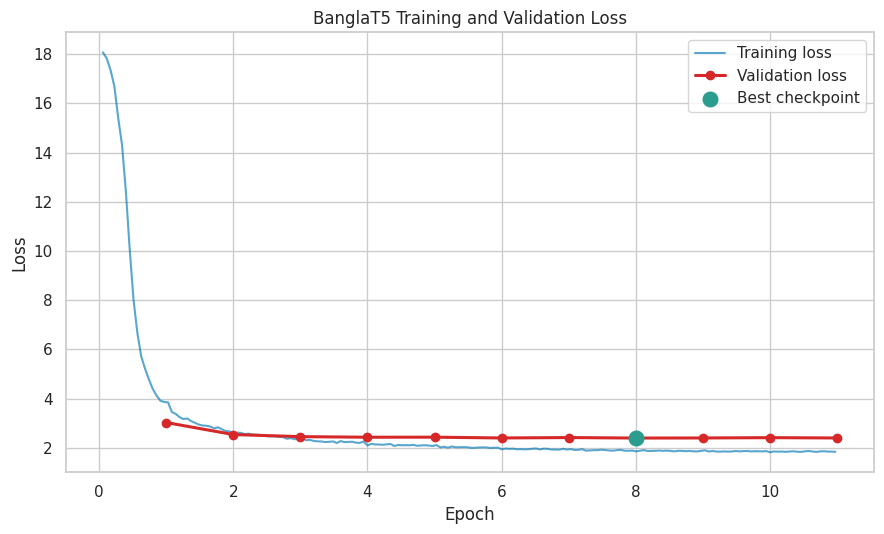

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
if TRAINING_SKIPPED or history_df.empty:
    print("Training was skipped (existing model reused), so there is no loss history to plot.")
else:
    train_log = history_df.dropna(subset=["loss"]) if "loss" in history_df else pd.DataFrame()
    eval_log = history_df.dropna(subset=["eval_loss"]) if "eval_loss" in history_df else pd.DataFrame()

    plt.figure(figsize=(9, 5.5))

    if not train_log.empty:
        plt.plot(train_log["epoch"], train_log["loss"], color="#0077B6", alpha=0.65, label="Training loss")

    if not eval_log.empty:
        plt.plot(eval_log["epoch"], eval_log["eval_loss"], color="#D62828", marker="o", linewidth=2.2, label="Validation loss")

    if best_checkpoint_path and not eval_log.empty:
        best_row = eval_log.loc[eval_log["eval_loss"].idxmin()]
        plt.scatter([best_row["epoch"]], [best_row["eval_loss"]], s=110, color="#2A9D8F", zorder=5, label="Best checkpoint")

    plt.title("BanglaT5 Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    save_figure("figure_09_training_validation_loss.png")


# Section 16: Validation-only decoding selection — greedy, beam-4 or beam-6

Generating beam=1, batch=16:   0%|          | 0/22 [00:00<?, ?it/s]

Generating beam=4, batch=16:   0%|          | 0/22 [00:00<?, ?it/s]

Generating beam=6, batch=16:   0%|          | 0/22 [00:00<?, ?it/s]

Selected beam width: 4


,Num_Beams,Validation_Sentences,BLEU,chrF,Generation_Minutes,Batch_Size_Used
1,4,350,50.856,75.421,0.161,16
2,6,350,50.831,75.382,0.180,16
0,1,350,50.143,74.897,0.140,16


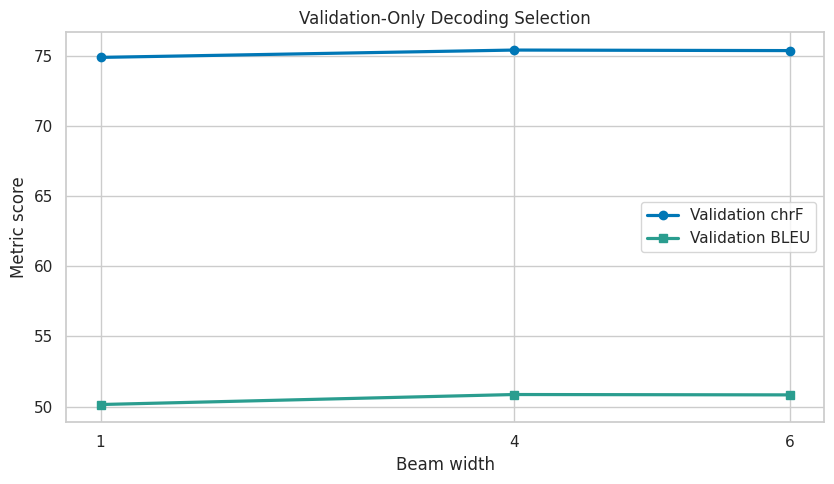

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
model.to("cuda")
model.eval()


def generate_predictions(texts, num_beams, requested_batch_size=EVAL_BATCH_SIZE):
    texts = list(texts)

    batch_options = []
    for batch_size in [requested_batch_size, 8, 4, 2, 1]:
        if batch_size not in batch_options:
            batch_options.append(batch_size)

    last_error = None

    for batch_size in batch_options:
        predictions = []
        try:
            for start in tqdm(
                range(0, len(texts), batch_size),
                desc=f"Generating beam={num_beams}, batch={batch_size}",
            ):
                batch = texts[start:start + batch_size]

                inputs = tokenizer(
                    batch, return_tensors="pt", padding=True, truncation=True, max_length=MAX_SOURCE_LEN,
                ).to("cuda")

                generation_kwargs = {
                    "max_new_tokens": MAX_TARGET_LEN,
                    "num_beams": num_beams,
                    "length_penalty": 1.0,
                }
                if num_beams > 1:
                    generation_kwargs["early_stopping"] = True

                with torch.inference_mode():
                    output_ids = model.generate(**inputs, **generation_kwargs)

                predictions.extend(tokenizer.batch_decode(output_ids, skip_special_tokens=True))

                del inputs
                del output_ids

            cleaned_predictions = []
            for prediction in predictions:
                cleaned_prediction = clean_text(prediction)
                cleaned_predictions.append("" if pd.isna(cleaned_prediction) else cleaned_prediction)

            return cleaned_predictions, batch_size

        except torch.cuda.OutOfMemoryError as error:
            last_error = error
            print(f"GPU memory limit at batch {batch_size}; retrying with a smaller batch.")
            torch.cuda.empty_cache()

    raise RuntimeError("Generation failed even with batch size 1") from last_error


val_tune_parts = []
for index, region in enumerate(REGIONS):
    region_subset = val_df[val_df.region == region]
    if len(region_subset):
        val_tune_parts.append(
            region_subset.sample(min(DECODING_TUNE_SAMPLES_PER_REGION, len(region_subset)), random_state=SEED + index)
        )

val_tune_df = pd.concat(val_tune_parts, ignore_index=True)

decode_rows = []

for number_of_beams in DECODING_CANDIDATES:
    started = time.time()
    val_predictions, used_batch = generate_predictions(val_tune_df.source_text.tolist(), number_of_beams)
    val_references = val_tune_df.target_text.tolist()

    decode_rows.append({
        "Num_Beams": number_of_beams,
        "Validation_Sentences": len(val_references),
        "BLEU": sacrebleu.corpus_bleu(val_predictions, [val_references]).score,
        "chrF": sacrebleu.corpus_chrf(val_predictions, [val_references]).score,
        "Generation_Minutes": (time.time() - started) / 60,
        "Batch_Size_Used": used_batch,
    })

decoding_df = pd.DataFrame(decode_rows).sort_values(
    ["chrF", "BLEU", "Num_Beams"], ascending=[False, False, True]
)

SELECTED_BEAMS = int(decoding_df.iloc[0]["Num_Beams"])

decoding_df.to_csv(TABLE_DIR / "validation_decoding_selection.csv", index=False)

print("Selected beam width:", SELECTED_BEAMS)
display(decoding_df.round(3))

plot_decode = decoding_df.sort_values("Num_Beams")

fig, ax1 = plt.subplots(figsize=(8.5, 5))
ax1.plot(plot_decode.Num_Beams, plot_decode.chrF, marker="o", linewidth=2.3, label="Validation chrF", color="#0077B6")
ax1.plot(plot_decode.Num_Beams, plot_decode.BLEU, marker="s", linewidth=2.3, label="Validation BLEU", color="#2A9D8F")
ax1.set_xlabel("Beam width")
ax1.set_ylabel("Metric score")
ax1.set_xticks(plot_decode.Num_Beams)
ax1.set_title("Validation-Only Decoding Selection")
ax1.legend()
save_figure("figure_10_validation_decoding_selection.png")


# Section 17: Locked test evaluation — generate predictions, then normalize

Every metric below (BLEU, chrF, BERTScore, exact match, region-wise scores,
bootstrap confidence intervals, error samples) is computed **after** this
single normalization step, using the same normalized text. No metric in this
notebook is computed from an earlier, unnormalized variable.

In [18]:
test_predictions, test_generation_batch_used = generate_predictions(test_df.source_text.tolist(), SELECTED_BEAMS)

test_results_df = test_df.copy().reset_index(drop=True)
test_results_df["prediction"] = test_predictions

# ---- Single evaluation-normalization function, applied before ANY metric ----

ZERO_WIDTH_PATTERN = re.compile(r"[\u200b\u200c\u200d\ufeff]")
WHITESPACE_PATTERN = re.compile(r"\s+")


def normalize_for_evaluation(text):
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = WHITESPACE_PATTERN.sub(" ", text).strip()
    return text


test_results_df["prediction"] = test_results_df["prediction"].apply(normalize_for_evaluation)
test_results_df["target_text"] = test_results_df["target_text"].apply(normalize_for_evaluation)

# Rebuild the list variables from the now-normalized DataFrame columns.
# Every metric from this point on reads test_predictions/references, so
# nothing downstream can accidentally use pre-normalization text.
test_predictions = test_results_df["prediction"].astype(str).tolist()
references = test_results_df["target_text"].astype(str).tolist()

test_results_df.to_csv(TABLE_DIR / "test_predictions_normalized.csv", index=False)

print("Test sentences:", len(test_results_df))
print("Predictions generated and normalized. No metric has been computed yet.")


Generating beam=4, batch=16:   0%|          | 0/89 [00:00<?, ?it/s]

Test sentences: 1419
Predictions generated and normalized. No metric has been computed yet.


# Section 18: Calculate BERTScore

In [19]:
# Release BanglaT5 GPU memory before loading multilingual BERT.
model.to("cpu")

if trainer is not None:
    trainer.optimizer = None
    trainer.lr_scheduler = None

torch.cuda.empty_cache()

from bert_score import score as bertscore_score


def calculate_bertscore(batch_size):
    return bertscore_score(
        test_predictions,
        references,
        model_type=BERTSCORE_MODEL,
        lang="bn",
        batch_size=batch_size,
        device="cuda",
        verbose=True,
        rescale_with_baseline=False,
    )


try:
    P, R, F1 = calculate_bertscore(batch_size=16)
except torch.cuda.OutOfMemoryError:
    print("GPU memory was insufficient at batch 16. Retrying with batch 4...")
    torch.cuda.empty_cache()
    P, R, F1 = calculate_bertscore(batch_size=4)

test_results_df["bertscore_precision"] = P.cpu().numpy()
test_results_df["bertscore_recall"] = R.cpu().numpy()
test_results_df["bertscore_f1"] = F1.cpu().numpy()

overall_bertscore = float(F1.mean())

del P, R, F1
torch.cuda.empty_cache()

print(f"Overall BERTScore F1: {overall_bertscore:.4f}")

# ---- 4th metric: multilingual sentence-embedding cosine similarity (STS) ----
# This is a genuinely distinct semantic metric from BERTScore: BERTScore does
# token-level greedy alignment between prediction and reference, while this
# embeds each FULL sentence into a single vector and compares whole-sentence
# meaning. Chosen over COMET specifically to avoid COMET's known dependency
# conflicts with very recent transformers releases.
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as _cosine_similarity

sts_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2", device="cuda")

sts_pred_embeddings = sts_model.encode(test_predictions, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
sts_ref_embeddings = sts_model.encode(references, batch_size=32, show_progress_bar=True, convert_to_numpy=True)

sts_scores = np.array([
    _cosine_similarity(sts_pred_embeddings[i:i + 1], sts_ref_embeddings[i:i + 1])[0][0]
    for i in range(len(test_predictions))
])

test_results_df["sts_cosine_similarity"] = sts_scores
overall_sts_similarity = float(sts_scores.mean())

del sts_model, sts_pred_embeddings, sts_ref_embeddings
torch.cuda.empty_cache()

print(f"Overall STS Cosine Similarity: {overall_sts_similarity:.4f}")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Overall STS Cosine Similarity: 0.9244


# Section 19: Overall and per-region metrics, exact match, bootstrap confidence intervals

In [20]:
from difflib import SequenceMatcher

# ---- Headline metrics, computed strictly from the normalized columns ----

overall_bleu = sacrebleu.corpus_bleu(test_predictions, [references]).score
overall_chrf = sacrebleu.corpus_chrf(test_predictions, [references]).score

exact_match_rate = 100 * np.mean(test_results_df.prediction == test_results_df.target_text)

print(f"Overall BLEU: {overall_bleu:.2f}")
print(f"Overall chrF: {overall_chrf:.2f}")
print(f"Overall BERTScore F1: {overall_bertscore:.4f}")
print(f"Exact match rate: {exact_match_rate:.2f}%")


def sentence_bleu(reference, prediction):
    return sacrebleu.sentence_bleu(prediction, [reference], use_effective_order=True).score


def sentence_chrf(reference, prediction):
    return sacrebleu.sentence_chrf(prediction, [reference]).score


test_results_df["sentence_bleu"] = [
    sentence_bleu(reference, prediction)
    for reference, prediction in zip(test_results_df.target_text, test_results_df.prediction)
]

test_results_df["sentence_chrf"] = [
    sentence_chrf(reference, prediction)
    for reference, prediction in zip(test_results_df.target_text, test_results_df.prediction)
]

test_results_df["character_similarity"] = [
    100 * SequenceMatcher(None, reference, prediction).ratio()
    for reference, prediction in zip(test_results_df.target_text, test_results_df.prediction)
]

test_results_df["target_words"] = test_results_df.target_text.str.split().str.len()
test_results_df["prediction_words"] = test_results_df.prediction.str.split().str.len()
test_results_df["word_length_difference"] = test_results_df.prediction_words - test_results_df.target_words


def quality_band(row):
    if row.prediction == row.target_text:
        return "Exact match"
    if row.sentence_chrf >= 80:
        return "Near match (chrF >= 80)"
    if row.sentence_chrf >= 50:
        return "Moderate (50 <= chrF < 80)"
    return "Difficult (chrF < 50)"


test_results_df["quality_band"] = test_results_df.apply(quality_band, axis=1)

# ---- Region-wise metrics ----

region_rows = []
for region in REGIONS:
    region_subset = test_results_df[test_results_df.region == region]
    if region_subset.empty:
        continue

    region_predictions = region_subset.prediction.tolist()
    region_references = region_subset.target_text.tolist()

    region_rows.append({
        "Region": region,
        "Test_Sentences": len(region_subset),
        "BLEU": sacrebleu.corpus_bleu(region_predictions, [region_references]).score,
        "chrF": sacrebleu.corpus_chrf(region_predictions, [region_references]).score,
        "BERTScore_F1": region_subset.bertscore_f1.mean(),
        "STS_Cosine_Similarity": region_subset.sts_cosine_similarity.mean(),
        "Exact_Match_Percent": 100 * np.mean(region_subset.prediction == region_subset.target_text),
        "Mean_Character_Similarity": region_subset.character_similarity.mean(),
    })

per_region_df = pd.DataFrame(region_rows)

macro_metrics = {
    "Macro_Region_BLEU": per_region_df.BLEU.mean(),
    "Macro_Region_chrF": per_region_df.chrF.mean(),
    "Macro_Region_BERTScore_F1": per_region_df.BERTScore_F1.mean(),
    "Macro_Region_STS_Cosine_Similarity": per_region_df.STS_Cosine_Similarity.mean(),
}

# ---- ID-cluster bootstrap confidence intervals ----
# Resample unique sentence IDs (not individual rows): regional rows sharing
# an ID are not independent observations, so row-level resampling would
# make the interval artificially narrow.

rng = np.random.default_rng(SEED)
boot_bleu, boot_chrf, boot_bert, boot_sts = [], [], [], []

number_of_test_samples = len(test_results_df)
_unique_ids_boot = test_results_df["id"].unique()
_id_to_positions_boot = test_results_df.reset_index(drop=True).groupby("id").indices

for _ in tqdm(range(BOOTSTRAP_SAMPLES), desc="ID-cluster bootstrap confidence intervals"):
    _sampled_ids = rng.choice(_unique_ids_boot, size=len(_unique_ids_boot), replace=True)
    sampled_indices = np.concatenate([_id_to_positions_boot[_sid] for _sid in _sampled_ids])

    sampled_predictions = [test_predictions[index] for index in sampled_indices]
    sampled_references = [references[index] for index in sampled_indices]

    boot_bleu.append(sacrebleu.corpus_bleu(sampled_predictions, [sampled_references]).score)
    boot_chrf.append(sacrebleu.corpus_chrf(sampled_predictions, [sampled_references]).score)
    boot_bert.append(float(test_results_df.bertscore_f1.iloc[sampled_indices].mean()))
    boot_sts.append(float(test_results_df.sts_cosine_similarity.iloc[sampled_indices].mean()))


def confidence_interval(values):
    return np.percentile(values, [2.5, 97.5]).tolist()


bleu_ci = confidence_interval(boot_bleu)
chrf_ci = confidence_interval(boot_chrf)
bert_ci = confidence_interval(boot_bert)
sts_ci = confidence_interval(boot_sts)

overall_metrics_df = pd.DataFrame([{
    "Model": "BanglaT5",
    "Model_ID": MODEL_NAME,
    "Test_Sentences": number_of_test_samples,
    "BLEU": overall_bleu,
    "BLEU_CI95_Lower": bleu_ci[0],
    "BLEU_CI95_Upper": bleu_ci[1],
    "chrF": overall_chrf,
    "chrF_CI95_Lower": chrf_ci[0],
    "chrF_CI95_Upper": chrf_ci[1],
    "BERTScore_F1": overall_bertscore,
    "BERTScore_CI95_Lower": bert_ci[0],
    "BERTScore_CI95_Upper": bert_ci[1],
    "STS_Cosine_Similarity": overall_sts_similarity,
    "STS_CI95_Lower": sts_ci[0],
    "STS_CI95_Upper": sts_ci[1],
    "Exact_Match_Percent": exact_match_rate,
    **macro_metrics,
    "Selected_Num_Beams": SELECTED_BEAMS,
    "Best_Validation_Loss": best_validation_loss,
    "Best_Checkpoint": best_checkpoint_path,
    "Training_Skipped": TRAINING_SKIPPED,
    "Training_Minutes": training_minutes,
}])

display(overall_metrics_df.round(4))
display(per_region_df.sort_values("BLEU", ascending=False).round(4))


Overall BLEU: 50.87
Overall chrF: 75.34
Overall BERTScore F1: 0.9392
Exact match rate: 24.81%


ID-cluster bootstrap confidence intervals:   0%|          | 0/300 [00:00<?, ?it/s]

,Model,Model_ID,Test_Sentences,BLEU,BLEU_CI95_Lower,BLEU_CI95_Upper,chrF,chrF_CI95_Lower,chrF_CI95_Upper,BERTScore_F1,...,Exact_Match_Percent,Macro_Region_BLEU,Macro_Region_chrF,Macro_Region_BERTScore_F1,Macro_Region_STS_Cosine_Similarity,Selected_Num_Beams,Best_Validation_Loss,Best_Checkpoint,Training_Skipped,Training_Minutes
0,BanglaT5,csebuetnlp/banglat5,1419,50.8723,47.5679,53.9418,75.3363,73.2854,77.2143,0.9392,...,24.8062,48.4433,73.6673,0.9348,0.9195,4,2.3942,banglat5_final_outputs/checkpoints/checkpoint-...,False,81.3678


,Region,Test_Sentences,BLEU,chrF,BERTScore_F1,STS_Cosine_Similarity,Exact_Match_Percent,Mean_Character_Similarity
2,Jashore,250,69.3089,86.9783,0.9696,0.9627,41.2000,94.9900
3,Rangpur,250,54.1403,79.4005,0.9475,0.9326,26.4000,91.4847
0,Pabna,250,50.6323,74.5240,0.9349,0.9076,24.4000,88.8543
1,Noakhali,250,47.4890,73.6003,0.9357,0.9260,20.8000,87.8828
5,Barishal,153,44.1746,71.3599,0.9314,0.9246,17.6471,87.7439
4,Mymensingh,153,41.7288,69.1542,0.9273,0.9146,18.3007,86.2973
6,Chittagong,113,31.6294,60.6537,0.8976,0.8685,13.2743,80.1589


# Section 20: Evaluation figures

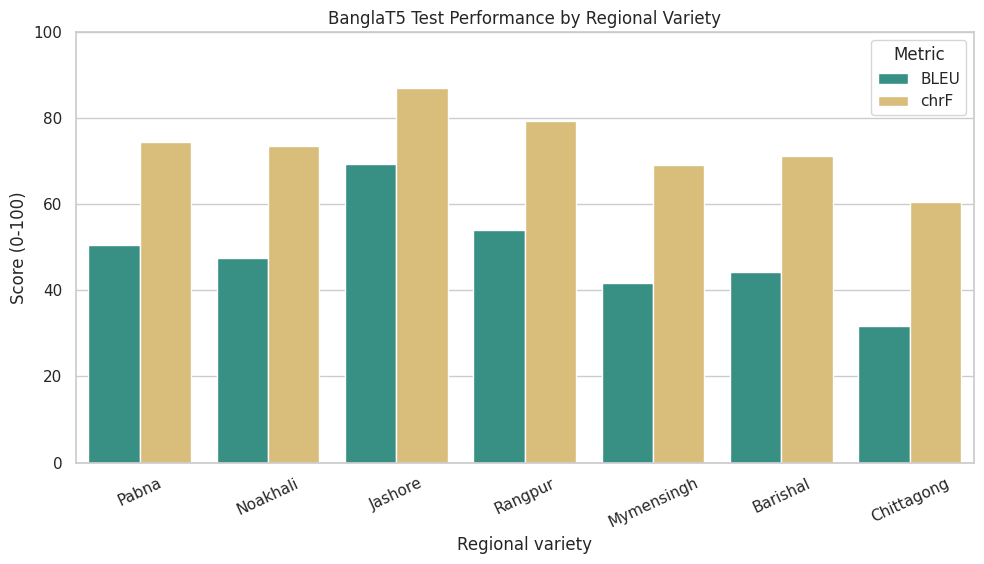

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

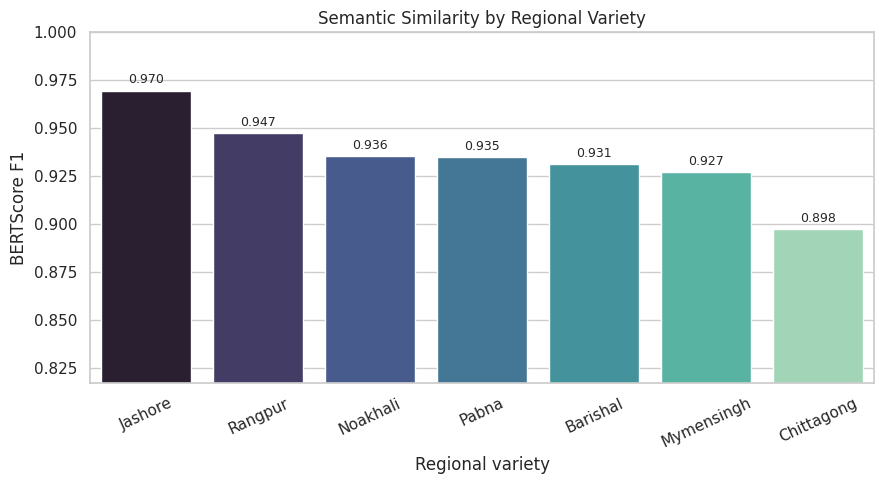

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

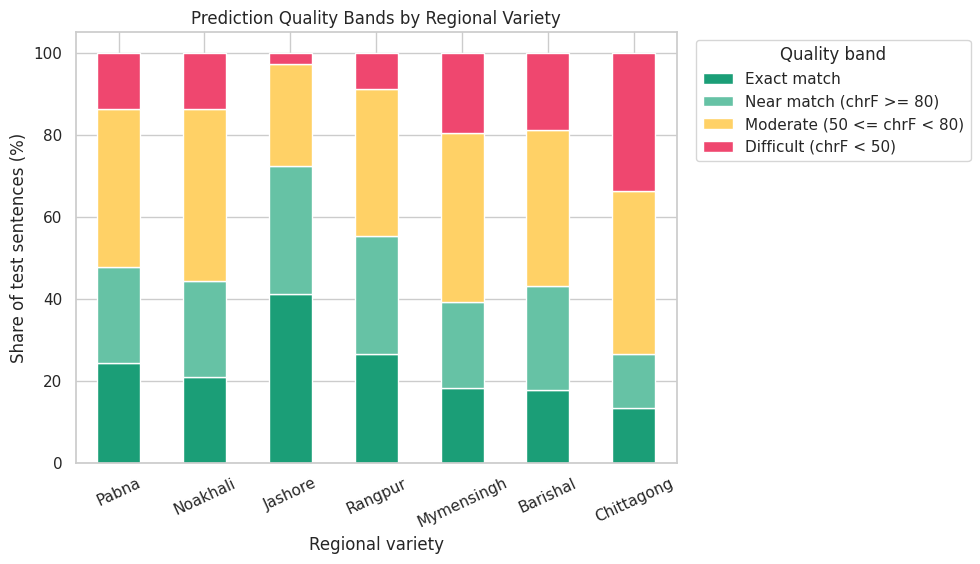

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

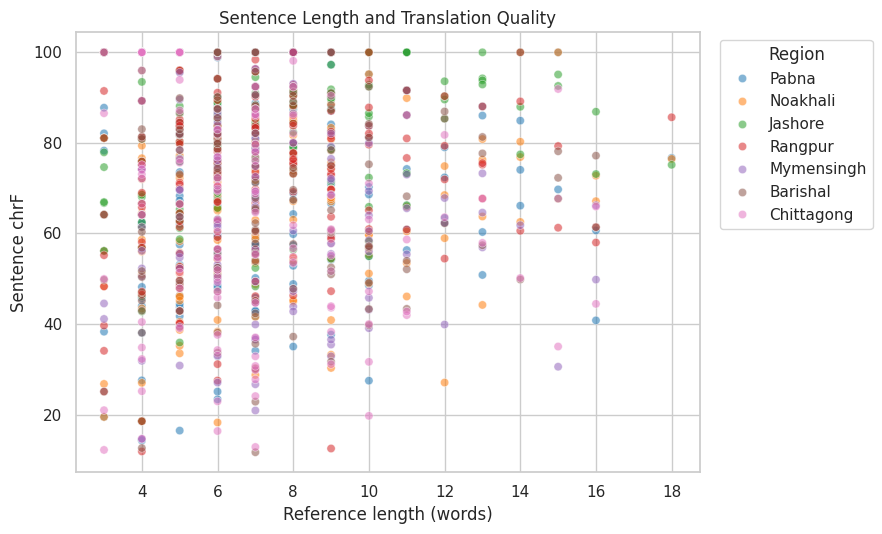

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

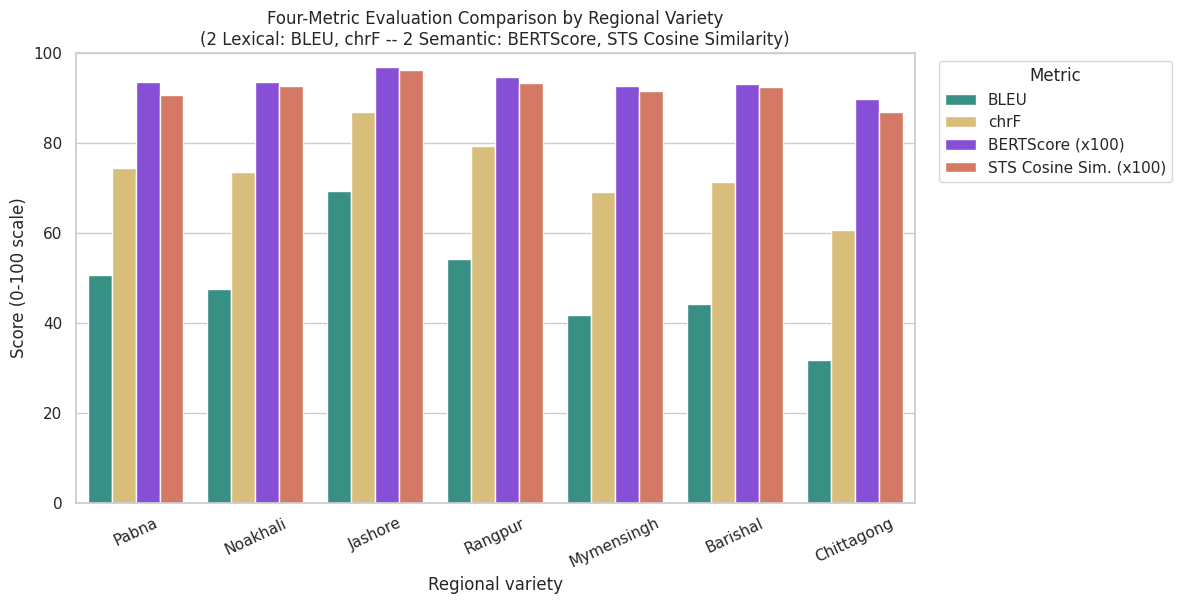

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

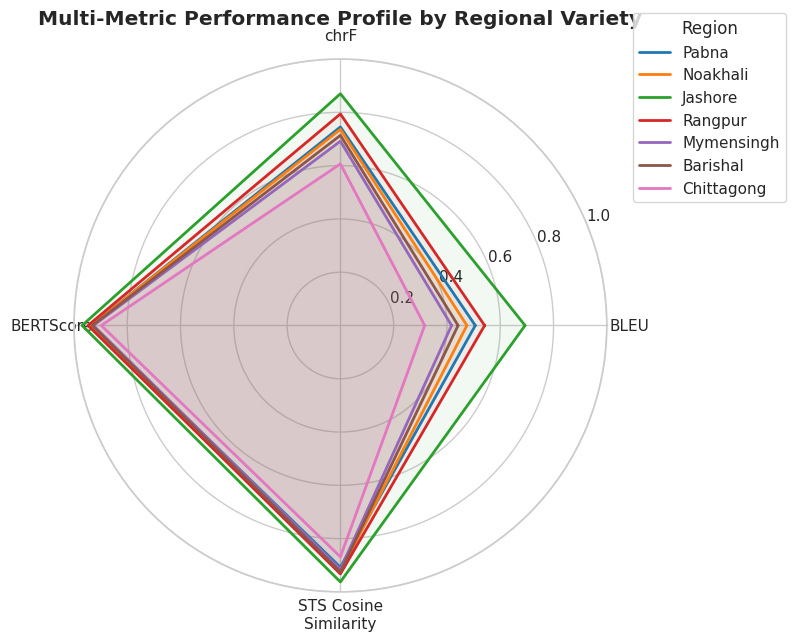

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

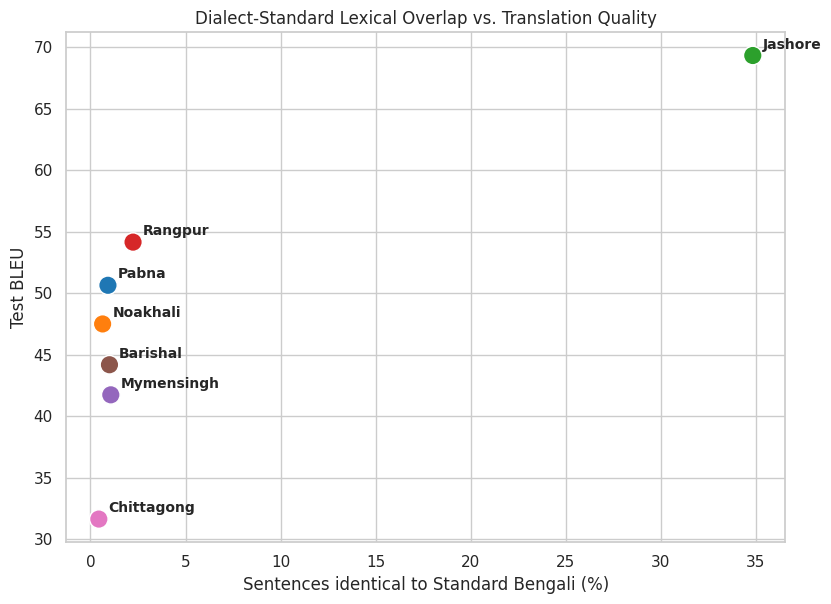

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

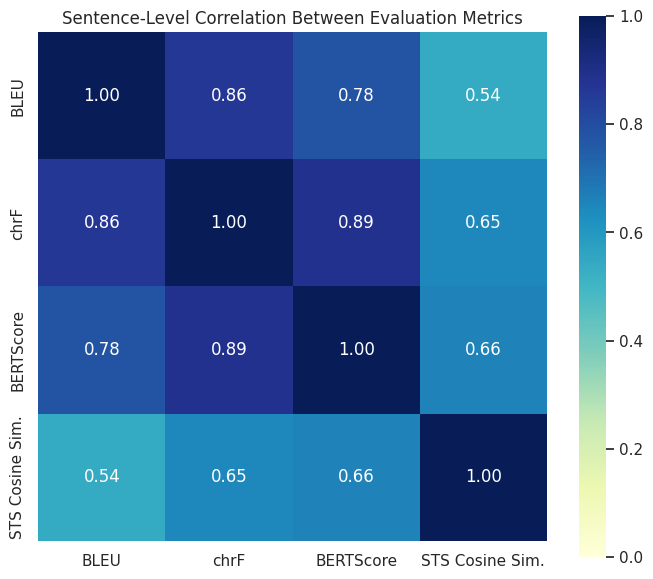

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
metrics_long = per_region_df.melt(id_vars="Region", value_vars=["BLEU", "chrF"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5.8))
ax = sns.barplot(data=metrics_long, x="Region", y="Score", hue="Metric", palette=["#2A9D8F", "#E9C46A"])
ax.set_title("BanglaT5 Test Performance by Regional Variety")
ax.set_xlabel("Regional variety")
ax.set_ylabel("Score (0-100)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)
save_figure("figure_11_per_region_bleu_chrf.png")


ordered = per_region_df.sort_values("BERTScore_F1", ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=ordered, x="Region", y="BERTScore_F1", hue="Region", palette="mako", legend=False)
ax.set_title("Semantic Similarity by Regional Variety")
ax.set_xlabel("Regional variety")
ax.set_ylabel("BERTScore F1")
ax.set_ylim(max(0, ordered.BERTScore_F1.min() - 0.08), 1.0)
ax.tick_params(axis="x", rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

save_figure("figure_12_per_region_bertscore.png")


band_order = ["Exact match", "Near match (chrF >= 80)", "Moderate (50 <= chrF < 80)", "Difficult (chrF < 50)"]

band_counts = (
    pd.crosstab(test_results_df.region, test_results_df.quality_band, normalize="index")
    .reindex(index=REGIONS, columns=band_order, fill_value=0) * 100
)

ax = band_counts.plot(kind="bar", stacked=True, figsize=(10, 5.8), color=["#1B9E77", "#66C2A5", "#FFD166", "#EF476F"])
ax.set_title("Prediction Quality Bands by Regional Variety")
ax.set_xlabel("Regional variety")
ax.set_ylabel("Share of test sentences (%)")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Quality band", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure("figure_13_prediction_quality_bands.png")


plt.figure(figsize=(9, 5.5))
sns.scatterplot(data=test_results_df, x="target_words", y="sentence_chrf", hue="region", alpha=0.55, palette="tab10")
plt.title("Sentence Length and Translation Quality")
plt.xlabel("Reference length (words)")
plt.ylabel("Sentence chrF")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure("figure_14_length_vs_sentence_chrf.png")


# ---------------------------------------------------------------
# Figure 15: All four metrics side-by-side per region
# (BERTScore and STS are x100 here purely for visual comparability
# with BLEU/chrF's 0-100 scale; the underlying values are unchanged.)
# ---------------------------------------------------------------
four_metric_df = per_region_df.copy()
four_metric_df["BERTScore_F1_x100"] = four_metric_df["BERTScore_F1"] * 100
four_metric_df["STS_Cosine_Similarity_x100"] = four_metric_df["STS_Cosine_Similarity"] * 100

four_metric_long = four_metric_df.melt(
    id_vars="Region",
    value_vars=["BLEU", "chrF", "BERTScore_F1_x100", "STS_Cosine_Similarity_x100"],
    var_name="Metric", value_name="Score",
)
four_metric_long["Metric"] = four_metric_long["Metric"].replace({
    "BERTScore_F1_x100": "BERTScore (x100)",
    "STS_Cosine_Similarity_x100": "STS Cosine Sim. (x100)",
})

plt.figure(figsize=(12, 6.2))
ax = sns.barplot(
    data=four_metric_long, x="Region", y="Score", hue="Metric",
    palette=["#2A9D8F", "#E9C46A", "#8338EC", "#E76F51"],
)
ax.set_title("Four-Metric Evaluation Comparison by Regional Variety\n(2 Lexical: BLEU, chrF -- 2 Semantic: BERTScore, STS Cosine Similarity)")
ax.set_xlabel("Regional variety")
ax.set_ylabel("Score (0-100 scale)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure("figure_15_four_metric_region_comparison.png")


# ---------------------------------------------------------------
# Figure 16: Radar chart -- all four metrics, all seven regions at a glance
# ---------------------------------------------------------------
radar_metrics = ["BLEU", "chrF", "BERTScore_F1", "STS_Cosine_Similarity"]
radar_labels = ["BLEU", "chrF", "BERTScore", "STS Cosine\nSimilarity"]

radar_df = per_region_df.set_index("Region")[radar_metrics].copy()
radar_df["BLEU"] = radar_df["BLEU"] / 100.0
radar_df["chrF"] = radar_df["chrF"] / 100.0

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8.5, 8.5), subplot_kw={"projection": "polar"})
region_colors = sns.color_palette("tab10", n_colors=len(REGIONS))

for region, color in zip(REGIONS, region_colors):
    if region not in radar_df.index:
        continue
    values = radar_df.loc[region, radar_metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=region, color=color)
    ax.fill(angles, values, alpha=0.06, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Multi-Metric Performance Profile by Regional Variety", fontsize=14.5, weight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), title="Region")
save_figure("figure_16_multi_metric_radar_chart.png")


# ---------------------------------------------------------------
# Figure 17: Dialect-to-Standard lexical similarity vs. translation quality
# Directly visualizes why Jashore scores highest: a large share of its
# sentences are lexically identical to Standard Bengali already.
# ---------------------------------------------------------------
similarity_vs_quality_df = per_region_df.merge(
    coverage_df[["Region", "Exact_Same_Percent"]], on="Region"
)

plt.figure(figsize=(8.5, 6.2))
ax = sns.scatterplot(
    data=similarity_vs_quality_df, x="Exact_Same_Percent", y="BLEU",
    hue="Region", s=180, palette="tab10", legend=False,
)
for _, row in similarity_vs_quality_df.iterrows():
    ax.annotate(
        row["Region"], (row["Exact_Same_Percent"], row["BLEU"]),
        textcoords="offset points", xytext=(7, 5), fontsize=10, weight="bold",
    )

ax.set_title("Dialect-Standard Lexical Overlap vs. Translation Quality")
ax.set_xlabel("Sentences identical to Standard Bengali (%)")
ax.set_ylabel("Test BLEU")
save_figure("figure_17_dialect_similarity_vs_quality.png")


# ---------------------------------------------------------------
# Figure 18: Sentence-level correlation between the four metrics
# ---------------------------------------------------------------
metric_corr_df = test_results_df[["sentence_bleu", "sentence_chrf", "bertscore_f1", "sts_cosine_similarity"]].copy()
metric_corr_df.columns = ["BLEU", "chrF", "BERTScore", "STS Cosine Sim."]
metric_correlation = metric_corr_df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(metric_correlation, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, square=True)
plt.title("Sentence-Level Correlation Between Evaluation Metrics")
save_figure("figure_18_metric_correlation_heatmap.png")


# Section 21: Export best, worst and exact-match samples

In [22]:
worst_samples = (
    test_results_df.sort_values(["region", "sentence_chrf"], ascending=[True, True])
    .groupby("region", group_keys=False).head(5)
)

best_nonexact_samples = (
    test_results_df[test_results_df.prediction != test_results_df.target_text]
    .sort_values(["region", "sentence_chrf"], ascending=[True, False])
    .groupby("region", group_keys=False).head(3)
)

exact_samples = (
    test_results_df[test_results_df.prediction == test_results_df.target_text]
    .groupby("region", group_keys=False).head(3)
)

sample_columns = [
    "id", "region", "dialect_text", "target_text", "prediction",
    "sentence_bleu", "sentence_chrf", "bertscore_f1", "sts_cosine_similarity", "quality_band",
]

worst_samples[sample_columns].to_csv(TABLE_DIR / "error_samples_worst_per_region.csv", index=False)
best_nonexact_samples[sample_columns].to_csv(TABLE_DIR / "strong_nonexact_samples_per_region.csv", index=False)
exact_samples[sample_columns].to_csv(TABLE_DIR / "exact_match_samples_per_region.csv", index=False)

quality_band_df = (
    test_results_df.groupby(["region", "quality_band"], observed=True)
    .size().rename("Sentences").reset_index()
)

print("Worst five samples per region (use for qualitative error analysis):")
display(worst_samples[sample_columns].head(14))


Worst five samples per region (use for qualitative error analysis):


,id,region,dialect_text,target_text,prediction,sentence_bleu,sentence_chrf,bertscore_f1,sts_cosine_similarity,quality_band
1203,0510,Barishal,হেই সময় পাশদিয়া এউক্কা হিয়াল গেছেলে,সেই সময় পাশ দিয়ে এক শিয়াল যাচ্ছিল,তখন পাশে একটি পুকুর ছিল,0.000000,11.664866,0.802335,0.833551,Difficult (chrF < 50)
1239,0813,Barishal,বেমালা ক্যাচাল লাইগ্গা যাইতে,বিশাল ক্যাচাল লেগে যেতো,অনেক ঝগড়ার জন্য যেতে হবে,0.000000,12.595830,0.712949,0.658068,Difficult (chrF < 50)
1266,1134,Barishal,ওর আর মোর স্কুলের দোস্তরা হগল কিছু জানত,ওর আর আমার স্কুল ফ্রেন্ডরা সব জানত,তার এবং আমার বিদ্যালয়ের বন্ধুরা সব কিছু জানত,7.267884,22.837504,0.710873,0.952600,Difficult (chrF < 50)
1159,0068,Barishal,বেমালা ভালো ছবি,অসম্ভব ভাল ছবি,খুব ভালো ছবি,27.516060,25.066967,0.836808,0.834404,Difficult (chrF < 50)
1299,1455,Barishal,মোর আস্ট মাসের এউক্কা পোলা আছে,আমার ৮ মাসের একটা ছেলে বাবু আছে,আমার আট বছরের একটি ছেলে আছে,9.042266,30.043885,0.859908,0.873589,Difficult (chrF < 50)
1312,0068,Chittagong,বেশি সুন্দর অইয়ে ছবি,অসম্ভব ভাল ছবি,খুব সুন্দর একটি ছবি,15.973578,12.181232,0.795084,0.777000,Difficult (chrF < 50)
1356,0510,Chittagong,হতক্ষন আগোদি আঁর ডাগোদি উজ্ঞো ইয়েল গিয়ি,সেই সময় পাশ দিয়ে এক শিয়াল যাচ্ছিল,অনেকদিন আগে আমার বাসায় একটা ছেলে ছিল,0.000000,12.826797,0.756251,0.517528,Difficult (chrF < 50)
1392,0813,Chittagong,বউত বড় ঝামেলা অই যাইতু,বিশাল ক্যাচাল লেগে যেতো,অনেক বড় ঝামেলা হয়ে যেত,0.000000,14.630490,0.759407,0.843990,Difficult (chrF < 50)
1362,0566,Chittagong,দুয়োরর ডাগোদি দুইজ্জণ বইয়েরর গিটার বাজার।,দরজার কাছে দুইজন বসে গিটার বাজাচ্ছে,গ্রামের চারদিকে দুইটি বইয়ের দোকান,0.000000,16.347990,0.719308,0.312760,Difficult (chrF < 50)
1325,0219,Chittagong,গানন্নান ফুনি আঁর চুঘত ফানি চলি আঁইস্সে হাছা ব...,গানটা শুনে চোখে পানি চলে আসলো সত্যি খুব ভালো ল...,গানটি শুনে আমার অনেক ভালো লেগেছে,4.955725,19.707011,0.774775,0.828658,Difficult (chrF < 50)


# Section 22: Export complete report package — tables, figures and final ZIP

In [23]:
run_config = {
    "research_direction": "Regional dialect to Standard Bengali",
    "model_name": MODEL_NAME,
    "seed": SEED,
    "source_file": DATA_FILE.name,
    "unique_ids": len(unique_ids),
    "unique_normalized_target_groups": len(unique_target_groups),
    "original_pairs": len(pairs_df),
    "train_pairs_before_balancing": len(train_df_raw),
    "train_pairs_after_balancing": len(train_df),
    "validation_pairs": len(val_df),
    "test_pairs": len(test_df),
    "split_ratios": [TRAIN_RATIO, VAL_RATIO, TEST_RATIO],
    "split_strategy_used": SPLIT_STRATEGY_USED,
    "balance_strategy": (
        "train-only oversampling to median regional training count"
        if BALANCE_LOW_RESOURCE_REGIONS else "none"
    ),
    "balance_target": balance_target,
    "max_source_length": MAX_SOURCE_LEN,
    "max_target_length": MAX_TARGET_LEN,
    "learning_rate": LEARNING_RATE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
    "label_smoothing": LABEL_SMOOTHING,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "lr_scheduler": "cosine",
    "fp16": False,
    "bf16": BF16_SUPPORTED,
    "selected_num_beams": SELECTED_BEAMS,
    "decoding_selected_on": "fixed region-balanced validation subset only",
    "gpu": GPU_NAME,
    "training_skipped_existing_model_reused": TRAINING_SKIPPED,
    "training_minutes": training_minutes,
    "best_checkpoint": best_checkpoint_path,
    "best_validation_loss": best_validation_loss,
    "sacrebleu_version": sacrebleu.__version__,
    "transformers_version": transformers.__version__,
    "datasets_version": datasets.__version__,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
}

with open(OUTPUT_ROOT / "run_config.json", "w", encoding="utf-8") as config_file:
    json.dump(run_config, config_file, ensure_ascii=False, indent=2, default=str)

overall_metrics_df.to_csv(TABLE_DIR / "overall_test_metrics.csv", index=False)
per_region_df.to_csv(TABLE_DIR / "per_region_test_metrics.csv", index=False)
quality_band_df.to_csv(TABLE_DIR / "prediction_quality_band_counts.csv", index=False)
test_results_df.to_csv(TABLE_DIR / "full_test_predictions_and_scores.csv", index=False)
train_df_raw.to_csv(TABLE_DIR / "train_pairs_original.csv", index=False)
train_df.to_csv(TABLE_DIR / "train_pairs_balanced.csv", index=False)
val_df.to_csv(TABLE_DIR / "validation_pairs.csv", index=False)
test_df.to_csv(TABLE_DIR / "test_pairs.csv", index=False)

with pd.ExcelWriter(OUTPUT_ROOT / "banglat5_report_tables.xlsx", engine="openpyxl") as writer:
    dataset_summary_df.to_excel(writer, sheet_name="Dataset Summary", index=False)
    duplicate_targets_df.to_excel(writer, sheet_name="Duplicate Target Audit", index=False)
    coverage_df.to_excel(writer, sheet_name="Regional Coverage", index=False)
    quality_audit_df.to_excel(writer, sheet_name="Cleaning Audit", index=False)
    long_summary_df.to_excel(writer, sheet_name="Long Format", index=False)
    split_summary_df.to_excel(writer, sheet_name="Split Distribution", index=False)
    leakage_audit_df.to_excel(writer, sheet_name="Leakage Audit", index=False)
    balance_df.to_excel(writer, sheet_name="Train Balancing", index=False)
    token_length_df.to_excel(writer, sheet_name="Token Length", index=False)
    decoding_df.to_excel(writer, sheet_name="Decoding Selection", index=False)
    overall_metrics_df.to_excel(writer, sheet_name="Overall Metrics", index=False)
    per_region_df.to_excel(writer, sheet_name="Per Region Metrics", index=False)
    quality_band_df.to_excel(writer, sheet_name="Quality Bands", index=False)
    worst_samples[sample_columns].to_excel(writer, sheet_name="Worst Error Samples", index=False)
    best_nonexact_samples[sample_columns].to_excel(writer, sheet_name="Strong Nonexact Samples", index=False)

training_time_line = (
    f"Training time (minutes): {training_minutes:.2f}"
    if training_minutes is not None
    else "Training time: N/A (existing trained model was reused, no training performed this run)"
)

summary_text = f"""BANGLAT5 FINAL RUN SUMMARY
Research direction: Regional dialect -> Standard Bengali
Source file: {DATA_FILE.name}
Model: {MODEL_NAME}
Seed: {SEED}

DATA AND SPLIT
Unique Standard Bengali IDs: {len(unique_ids)}
Total dialect-standard pairs: {len(pairs_df)}
Train/validation/test pairs before balancing: {len(train_df_raw)} / {len(val_df)} / {len(test_df)}
Training pairs after train-only balancing: {len(train_df)}
Exact ID overlap across splits: 0
Exact target overlap across splits: 0
Split strategy used: {SPLIT_STRATEGY_USED}

TRAINING
Maximum epochs: {MAX_EPOCHS}
Best validation loss: {best_validation_loss}
Best checkpoint: {best_checkpoint_path}
{training_time_line}
FP16: False
BF16: {BF16_SUPPORTED}

LOCKED TEST RESULTS (2 lexical + 2 semantic metrics)
BLEU: {overall_bleu:.4f} (95% bootstrap CI {bleu_ci[0]:.4f}-{bleu_ci[1]:.4f})
chrF: {overall_chrf:.4f} (95% bootstrap CI {chrf_ci[0]:.4f}-{chrf_ci[1]:.4f})
BERTScore F1: {overall_bertscore:.6f} (95% bootstrap CI {bert_ci[0]:.6f}-{bert_ci[1]:.6f})
STS Cosine Similarity: {overall_sts_similarity:.6f} (95% bootstrap CI {sts_ci[0]:.6f}-{sts_ci[1]:.6f})
Exact match rate: {exact_match_rate:.4f}%
Selected beam width: {SELECTED_BEAMS} (selected on validation only)

INTERPRETATION CAUTION
Automatic metrics must be interpreted together. chrF is useful for Bengali morphology and spelling variation,
while BERTScore captures semantic similarity. Qualitative examples should be independently reviewed by fluent
speakers. The test set was not used for training, early stopping, balancing, or decoding selection.
"""

with open(OUTPUT_ROOT / "methodology_and_results_summary.txt", "w", encoding="utf-8") as summary_file:
    summary_file.write(summary_text)

reference_text = """BanglaT5 model card: https://huggingface.co/csebuetnlp/banglat5
BanglaNLG/BanglaT5 paper: https://aclanthology.org/2023.findings-eacl.54/
Hugging Face translation guide: https://huggingface.co/docs/transformers/tasks/translation
Hugging Face Trainer API: https://huggingface.co/docs/transformers/main_classes/trainer
SacreBLEU: https://github.com/mjpost/sacrebleu
BERTScore: https://github.com/Tiiiger/bert_score
"""

with open(OUTPUT_ROOT / "references_for_report.txt", "w", encoding="utf-8") as reference_file:
    reference_file.write(reference_text)

manifest = sorted(
    [str(path.relative_to(OUTPUT_ROOT)) for path in FIG_DIR.rglob("*") if path.is_file()]
    + [str(path.relative_to(OUTPUT_ROOT)) for path in TABLE_DIR.rglob("*") if path.is_file()]
    + [path.name for path in OUTPUT_ROOT.iterdir() if path.is_file()]
)

with open(OUTPUT_ROOT / "artifact_manifest.txt", "w", encoding="utf-8") as manifest_file:
    manifest_file.write("\n".join(manifest))

REPORT_PACKAGE_DIR = Path("BanglaT5_Report_Artifacts")

if REPORT_PACKAGE_DIR.exists():
    shutil.rmtree(REPORT_PACKAGE_DIR)

REPORT_PACKAGE_DIR.mkdir()

shutil.copytree(FIG_DIR, REPORT_PACKAGE_DIR / "figures")
shutil.copytree(TABLE_DIR, REPORT_PACKAGE_DIR / "tables")

for root_file in [
    OUTPUT_ROOT / f"split_assignments_seed{SEED}.csv",
    OUTPUT_ROOT / "banglat5_report_tables.xlsx",
    OUTPUT_ROOT / "run_config.json",
    OUTPUT_ROOT / "methodology_and_results_summary.txt",
    OUTPUT_ROOT / "references_for_report.txt",
    OUTPUT_ROOT / "artifact_manifest.txt",
]:
    shutil.copy2(root_file, REPORT_PACKAGE_DIR / root_file.name)

REPORT_ZIP = shutil.make_archive("BanglaT5_Report_Artifacts", "zip", root_dir=REPORT_PACKAGE_DIR)
print("Created report package:", REPORT_ZIP)

if CREATE_MODEL_ZIP:
    MODEL_ZIP = shutil.make_archive("BanglaT5_Trained_Model", "zip", root_dir=MODEL_DIR)
    print("Created model package:", MODEL_ZIP)

if AUTO_DOWNLOAD_REPORT_ZIP:
    files.download(REPORT_ZIP)

if CREATE_MODEL_ZIP:
    files.download(MODEL_ZIP)


Created report package: /content/BanglaT5_Report_Artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Section 23: Inference test — translate a new regional sentence

In [24]:
inference_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=False)
inference_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR).to("cuda").eval()


def translate_dialect(text, region):
    if region not in REGIONS:
        raise ValueError(f"Region must be one of: {REGIONS}")

    cleaned = clean_text(text)
    prompt = f"translate {region} to Bangla: {cleaned}"

    inputs = inference_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SOURCE_LEN).to("cuda")

    generation_kwargs = {
        "max_new_tokens": MAX_TARGET_LEN,
        "num_beams": SELECTED_BEAMS,
        "length_penalty": 1.0,
    }
    if SELECTED_BEAMS > 1:
        generation_kwargs["early_stopping"] = True

    with torch.inference_mode():
        output = inference_model.generate(**inputs, **generation_kwargs)

    return inference_tokenizer.decode(output[0], skip_special_tokens=True)


print(translate_dialect("\u0995\u09cd\u09af\u09be\u09ac\u09be \u0986\u099b\u09cd\u09af\u09be\u0993?", "Pabna"))


কেমন আছো ?
